> **Notebook cell 01/36 — Project overview and execution guide**

# QI26-20 — A Reproducible QUBO–QAOA Benchmark for Generalized Bipartite Assignment on NISQ Hardware

This notebook is the executable scientific artifact for a controlled comparison of classical optimization, standard QAOA, and Grover-Mixer QAOA (GM-QAOA) on small generalized bipartite-assignment instances.

## Research pipeline

1. **Mathematical formulation and QUBO derivation.** Define the assignment variables, objective, constraints, penalty weights, QUBO coefficients, and capacity extension.
2. **Synthetic instances and validation.** Generate reproducible affinity matrices and verify one-to-one and exact-capacity constraints.
3. **Classical baselines.** Compare exact enumeration, the Hungarian algorithm, greedy assignment, and simulated annealing using the same score definition.
4. **Standard QAOA with Qiskit.** Map the QUBO to an Ising Hamiltonian, optimize deterministic runs for $p\in\{1,2,3\}$, and analyze feasibility and optimality probabilities.
5. **GM-QAOA.** Prepare an equal superposition of feasible states for the three fixed Phase-1 instances and apply a feasible-subspace-preserving mixer.
6. **NISQ hardware analysis.** Compare logical and physical topology, transpilation overhead, ideal distributions, and IBM Quantum measurements.
7. **Scientific traceability.** Export experiment tables, maintain a claims checklist, and state the limitations of the current small-instance benchmark.

## Execution modes

- **Ideal simulation:** deterministic statevector experiments for the classical, standard-QAOA, and GM-QAOA comparisons.
- **Fake IBM backend:** selected automatically when no IBM token is available.
- **IBM Quantum hardware:** enabled only with a user-supplied `QISKIT_IBM_TOKEN` through Colab Secrets or an environment variable.

> **Security:** this public notebook contains no IBM Quantum credential. Never paste a real token into a notebook that will be committed to GitHub.

Run the cells sequentially from top to bottom. The numerical tables included in the repository were extracted from the executed outputs preserved in this notebook.


> **Notebook cell 02/36 — Mathematical formulation and QUBO overview**

# 1. Mathematical Formulation and QUBO Derivation

**Primary owner:** Jiya Maurya  
**Support:** Satkar Juneja, Ilia Fazeli  
**Decision rationale:** this track defines the mathematical foundation that every other track will use: variables, constraints, objective function, penalty terms, and the explicit QUBO representation.

## Goal

Define the initial assignment optimization problem and convert it into a Quadratic Unconstrained Binary Optimization problem.

We model two disjoint sets:

$$
\mathcal{A} = \{a_1, a_2, \ldots, a_n\}
$$

$$
\mathcal{R} = \{r_1, r_2, \ldots, r_m\}
$$

where $\mathcal{A}$ is the set of agents and $\mathcal{R}$ is the set of resources.

For every pair $(a_i,r_j)$, define a binary variable:

$$
x_{ij} \in \{0,1\}
$$

with interpretation:

$$
x_{ij} =
\begin{cases}
1, & \text{if agent } a_i \text{ is assigned to resource } r_j, \\
0, & \text{otherwise.}
\end{cases}
$$

Let $S \in \mathbb{R}^{n \times m}$ be the affinity matrix. The entry $S_{ij}$ measures the benefit of assigning agent $a_i$ to resource $r_j$.

The classical objective is:

$$
\max_x \sum_{i=1}^{n}\sum_{j=1}^{m} S_{ij}x_{ij}
$$

For QUBO and QAOA, we use a minimization form:

$$
E_{\mathrm{score}}(x) = -\sum_{i=1}^{n}\sum_{j=1}^{m} S_{ij}x_{ij}
$$

For the initial **1-to-1 assignment** case, we impose:

$$
\sum_{j=1}^{m}x_{ij}=1
\qquad
\forall i \in \{1,\ldots,n\}
$$

$$
\sum_{i=1}^{n}x_{ij}\leq 1
\qquad
\forall j \in \{1,\ldots,m\}
$$

The initial QUBO objective is:

$$
Q(x)
=
-\sum_{i=1}^{n}\sum_{j=1}^{m}S_{ij}x_{ij}
+
\lambda_{\mathcal{A}}\sum_{i=1}^{n}\left(\sum_{j=1}^{m}x_{ij}-1\right)^2
+
\lambda_{\mathcal{R}}\sum_{j=1}^{m}\sum_{1\leq i<k\leq n}x_{ij}x_{kj}
$$

where $\lambda_{\mathcal{A}}>0$ penalizes agents not assigned exactly once, and $\lambda_{\mathcal{R}}>0$ penalizes assigning the same resource to more than one agent.

## Track 1 deliverables

1. Mathematical problem definition.
2. QUBO derivation for the 1-to-1 case.
3. Extension notes for 1-to-N capacity constraints.
4. Penalty-weight justification.
5. Explicit QUBO matrix or coefficient dictionary.
6. A short mathematical note with assumptions and limitations.


> **Notebook cell 03/36 — Detailed derivation, penalty bounds, and capacity extension**

## Detailed QUBO Derivation, Penalty Bounds, and Capacity Extension

**Contributor:** Jiya Maurya

## 1. Problem Definition

### 1.1 Sets and decision variables

We model two finite, disjoint sets

$$\mathcal{A} = \{a_1, a_2, \dots, a_n\}, \qquad \mathcal{R} = \{r_1, r_2, \dots, r_m\},$$

where $\mathcal{A}$ is the set of **agents** and $\mathcal{R}$ is the set of
**resources**. For every pair $(a_i, r_j)$ we introduce a binary decision variable

$$x_{ij} \in \{0,1\}, \qquad
x_{ij} =
\begin{cases}
1, & \text{if agent } a_i \text{ is assigned to resource } r_j, \\
0, & \text{otherwise,}
\end{cases}$$

giving $nm$ binary variables in total. We write
$x = (x_{ij})_{i\in[n],\,j\in[m]} \in \{0,1\}^{nm}$, with $[n] = \{1,\dots,n\}$.

### 1.2 Affinity matrix and objective

Let $S \in \mathbb{R}^{n \times m}$ be the **affinity matrix**, where $S_{ij}$
measures the benefit of assigning agent $a_i$ to resource $r_j$.

**Assumption (A1) — nonnegative affinities:** $S_{ij} \ge 0$ for all $i, j$.
This is without loss of generality: any real $S$ can be shifted by a constant
$S_{ij} \mapsto S_{ij} - \min_{k\ell} S_{k\ell}$, which shifts the objective of
every feasible 1-to-1 assignment by the same constant
$-\,n \cdot \min_{k\ell} S_{k\ell}$ (each feasible assignment activates exactly
$n$ entries) and therefore preserves the optimizer.

**Assumption (A2) — feasibility:** $n \le m$, so that a 1-to-1 assignment of
all agents exists.

The classical optimization problem is

$$\max_{x \in \mathcal{F}} \; \sum_{i=1}^{n} \sum_{j=1}^{m} S_{ij}\, x_{ij},$$

over the feasible set

$$\mathcal{F} \;=\; \Bigl\{ x \in \{0,1\}^{nm} \;:\; \sum_{j=1}^{m} x_{ij} = 1 \;\; \forall i \in [n], \quad \sum_{i=1}^{n} x_{ij} \le 1 \;\; \forall j \in [m] \Bigr\}.$$

The equality constraints require every agent to be assigned to exactly one
resource; the inequality constraints forbid assigning any resource to more than
one agent. When $n = m$, this is exactly the **Linear Assignment Problem**
(equivalently, maximum-weight perfect matching on the complete bipartite graph
$K_{n,n}$ with edge weights $S_{ij}$); for $n < m$ it is the rectangular
assignment / maximum-weight bipartite matching variant.

Since QUBO and QAOA are formulated as minimization, we use the sign-flipped
score energy

$$E_{\text{score}}(x) \;=\; -\sum_{i=1}^{n}\sum_{j=1}^{m} S_{ij}\, x_{ij},$$

so that $\min_{x\in\mathcal{F}} E_{\text{score}}(x)$ is equivalent to the
maximization above.

---

## 2. QUBO Derivation

### 2.1 The QUBO objective

With penalty weights $\lambda_{\mathcal{A}} > 0$ and $\lambda_{\mathcal{R}} > 0$,
the initial (1-to-1) QUBO objective is

$$Q(x) \;=\; -\sum_{i=1}^{n}\sum_{j=1}^{m} S_{ij}\,x_{ij} \;+\; \lambda_{\mathcal{A}} \sum_{i=1}^{n}\Bigl(\sum_{j=1}^{m} x_{ij} - 1\Bigr)^{2} \;+\; \lambda_{\mathcal{R}} \sum_{j=1}^{m}\sum_{1 \le i < k \le n} x_{ij}\,x_{kj}.$$

For each resource $j$, writing $c_j = \sum_{i=1}^{n} x_{ij}$ for the number of
agents assigned to it, the pairwise penalty satisfies

$$\sum_{1 \le i < k \le n} x_{ij}\, x_{kj} \;=\; \binom{c_j}{2},$$

which is $0$ if and only if $c_j \le 1$ and strictly positive otherwise — an
exact, slack-free quadratic encoding of the inequality constraint
$\sum_i x_{ij} \le 1$.

On the feasible set $\mathcal{F}$ both penalty terms vanish, so
$Q(x) = E_{\text{score}}(x)$ for all $x \in \mathcal{F}$; the constrained and
penalized problems agree on feasible points by construction. Section 3 gives
conditions on $(\lambda_{\mathcal{A}}, \lambda_{\mathcal{R}})$ under which the
global minimizers of $Q$ over all of $\{0,1\}^{nm}$ are guaranteed to lie in
$\mathcal{F}$.

### 2.2 Expansion into standard QUBO coefficients

Using the Boolean identity $x_{ij}^2 = x_{ij}$, the agent penalty expands as

$$\Bigl(\sum_{j} x_{ij} - 1\Bigr)^{2}
= \sum_{j} x_{ij} \;+\; 2\!\!\sum_{1 \le j < \ell \le m}\!\! x_{ij} x_{i\ell} \;-\; 2\sum_{j} x_{ij} \;+\; 1
= -\sum_{j} x_{ij} \;+\; 2\!\!\sum_{1 \le j < \ell \le m}\!\! x_{ij} x_{i\ell} \;+\; 1.$$

Collecting terms, $Q(x)$ takes the standard form

$$Q(x) \;=\; \sum_{(i,j)} q_{ij}\, x_{ij} \;+\; \sum_{\kappa(i,j) < \kappa(k,\ell)} Q_{(i,j),(k,\ell)}\, x_{ij}\, x_{k\ell} \;+\; C,$$

where the quadratic sum runs over unordered pairs, listed once each in the
order of the flattened index $\kappa$ defined below, and (all unlisted
quadratic coefficients equal to zero):

| Term | Coefficient | Origin |
|---|---|---|
| Linear, every variable $x_{ij}$ | $q_{ij} = -S_{ij} - \lambda_{\mathcal{A}}$ | score + expanded agent penalty |
| Quadratic, same agent, $x_{ij}x_{i\ell}$, $j < \ell$ | $2\lambda_{\mathcal{A}}$ | agent penalty cross terms |
| Quadratic, same resource, $x_{ij}x_{kj}$, $i < k$ | $\lambda_{\mathcal{R}}$ | resource penalty |
| Constant offset | $C = n\,\lambda_{\mathcal{A}}$ | agent penalty constants |

**Matrix form.** We flatten indices via $\kappa(i,j) = i\cdot m + j$, where $i$
and $j$ are read zero-based ($i \in \{0,\dots,n-1\}$, $j \in \{0,\dots,m-1\}$)
to match the reference code; equivalently
$\kappa(i,j) = (i-1)m + (j-1)$ for the one-based indices of §1.

We then define the upper-triangular matrix $\mathbf{Q} \in \mathbb{R}^{nm \times nm}$ with diagonal
entries $\mathbf{Q}_{\kappa\kappa} = q_{ij}$ and off-diagonal entries as in the
table. Then

$$Q(x) \;=\; x^{\top} \mathbf{Q}\, x \;+\; C, \qquad x \in \{0,1\}^{nm},$$

where the diagonal correctly absorbs the linear terms because
$x_\kappa^2 = x_\kappa$.

**Problem size.** The 1-to-1 QUBO uses exactly $nm$ binary variables (qubits),
with $n\binom{m}{2}$ same-row and $m\binom{n}{2}$ same-column quadratic
couplings; the coupling graph is the union of $n$ row-cliques $K_m$ and $m$
column-cliques $K_n$ (the rook's graph on the $n \times m$ grid).

---

## 3. Penalty-Weight Justification

The penalties must be large enough that no infeasible bitstring can undercut
the best feasible one. The following proposition gives a sufficient condition,
under the same assumptions as before (A1: $S \ge 0$; A2: $n \le m$). Let
$S_{\max} = \max_{i,j} S_{ij}$.

**Proposition 1 (feasibility of the ground state).** If $\lambda_{\mathcal{A}} > S_{\max}$
and $\lambda_{\mathcal{R}} > S_{\max}$, then every global minimizer of $Q$ over
$\{0,1\}^{nm}$ lies in $\mathcal{F}$. Consequently, the global minimizers of
$Q$ are exactly the maximum-affinity 1-to-1 assignments, and
$\min_x Q(x) = -\max_{x \in \mathcal{F}} \sum_{ij} S_{ij}\, x_{ij}$.

*Proof.* We show that for every infeasible $x$ there exists $x'$ with
$Q(x') < Q(x)$; hence no infeasible point can be a global minimizer. Write
$s_i = \sum_j x_{ij}$ (row sums) and $c_j = \sum_i x_{ij}$ (column sums). If
$x \notin \mathcal{F}$, at least one of the following cases applies.


**Case A: some row has $s_i \ge 2$.** Pick any $j$ with $x_{ij} = 1$ and set $x_{ij} \to 0$. The score energy increases by $S_{ij} \le S_{\max}$. The agent
penalty changes by
$\lambda_{\mathcal{A}}\bigl[(s_i-2)^2 - (s_i-1)^2\bigr] = \lambda_{\mathcal{A}}(3-2s_i) \le -\lambda_{\mathcal{A}}$,
and the resource penalty cannot increase. Net change
$\le S_{\max} - \lambda_{\mathcal{A}} < 0$.


**Case B: all rows have $s_i \le 1$, but some column has $c_j \ge 2$.** The
total number of assigned pairs is $T = \sum_i s_i \le n \le m$, while column
$j$ holds at least $2$ of them; hence some column $j'$ has $c_{j'} = 0$. Pick
any $i$ with $x_{ij}=1$ and move it: set $x_{ij} \to 0$, $x_{ij'} \to 1$. Row
sums are unchanged, so the agent penalty is unchanged. The resource penalty
decreases by
$\lambda_{\mathcal{R}}\bigl[\binom{c_j}{2} - \binom{c_j-1}{2}\bigr] = \lambda_{\mathcal{R}}(c_j - 1) \ge \lambda_{\mathcal{R}}$.
The score energy changes by $S_{ij} - S_{ij'} \le S_{\max}$ (using $S \ge 0$).
Net change $\le S_{\max} - \lambda_{\mathcal{R}} < 0$.


**Case C: no row exceeds $1$ and no column exceeds $1$, but some row has
$s_i = 0$.** Then $T \le n-1 < m$, so a column $j'$ with $c_{j'}=0$ exists. Set
$x_{ij'} \to 1$: the agent penalty decreases by $\lambda_{\mathcal{A}}$, the
resource penalty is unchanged, and the score energy changes by
$-S_{ij'} \le 0$. Net change $\le -\lambda_{\mathcal{A}} < 0$.

Every infeasible $x$ falls into Case A, B, or C (if some row exceeds $1$, Case
A applies; otherwise all rows are $\le 1$, and either some column collides —
Case B — or some agent is unassigned — Case C), so infeasible points are never
minimizers. On $\mathcal{F}$ the penalties vanish and $Q = E_{\text{score}}$. $\blacksquare$

**Notes.**
1. The condition is sufficient, not necessary. Smaller penalties may happen to
   yield a feasible minimizer on a particular instance, but only the bound
   above is instance-independent (given $S_{\max}$).
2. Implemented choice: the reference code uses the conservative value
   $\lambda_{\mathcal{A}} = \lambda_{\mathcal{R}} = n\,m\,\max_{i,j}|S_{ij}|$,
   which satisfies Proposition 1 with a wide margin (it is also at least
   $\sum_{ij}|S_{ij}|$, the sum of all absolute affinities and hence an upper
   bound on any attainable score, so no combination of violations can ever be
   profitable).


---

## 4. Explicit QUBO for the Reference Instance ($n = m = 3$)

### 4.1 Instance data

$$S = \begin{pmatrix} 0.90 & 0.20 & 0.40 \\ 0.30 & 0.85 & 0.50 \\ 0.45 & 0.35 & 0.95 \end{pmatrix},
\qquad
\lambda_{\mathcal{A}} = \lambda_{\mathcal{R}} = n\,m\,S_{\max} = 9 \times 0.95 = 8.55,
\qquad C = n\,\lambda_{\mathcal{A}} = 25.65.$$

Variables are ordered $x_{00}, x_{01}, x_{02}, x_{10}, x_{11}, x_{12}, x_{20}, x_{21}, x_{22}$
via $\kappa(i,j) = 3i + j$ (zero-based).

### 4.2 QUBO matrix

$Q(x) = x^{\top} \mathbf{Q}\, x + 25.65$ with the upper-triangular matrix

$$\mathbf{Q} =
\begin{pmatrix}
-9.45 & 17.10 & 17.10 & 8.55 & \cdot & \cdot & 8.55 & \cdot & \cdot \\
\cdot & -8.75 & 17.10 & \cdot & 8.55 & \cdot & \cdot & 8.55 & \cdot \\
\cdot & \cdot & -8.95 & \cdot & \cdot & 8.55 & \cdot & \cdot & 8.55 \\
\cdot & \cdot & \cdot & -8.85 & 17.10 & 17.10 & 8.55 & \cdot & \cdot \\
\cdot & \cdot & \cdot & \cdot & -9.40 & 17.10 & \cdot & 8.55 & \cdot \\
\cdot & \cdot & \cdot & \cdot & \cdot & -9.05 & \cdot & \cdot & 8.55 \\
\cdot & \cdot & \cdot & \cdot & \cdot & \cdot & -9.00 & 17.10 & 17.10 \\
\cdot & \cdot & \cdot & \cdot & \cdot & \cdot & \cdot & -8.90 & 17.10 \\
\cdot & \cdot & \cdot & \cdot & \cdot & \cdot & \cdot & \cdot & -9.50
\end{pmatrix}$$

(dots denote $0$). Equivalently, as a coefficient dictionary: diagonal
$\mathbf{Q}_{\kappa\kappa} = -S_{ij} - 8.55$; same-row pairs carry
$2\lambda_{\mathcal{A}} = 17.10$; same-column pairs carry
$\lambda_{\mathcal{R}} = 8.55$.

---

## 5. Extension Notes: 1-to-N Capacity Constraints

To generalize the resource side from "at most one agent" to a capacity
$C_j \in \mathbb{Z}_{\ge 1}$ per resource,

$$\sum_{i=1}^{n} x_{ij} \le C_j \qquad \forall j \in [m],$$

the following points govern the QUBO extension.

1. **The pairwise trick is special to $C_j = 1$.** Since
   $\sum_{i<k} x_{ij}x_{kj} = \binom{c_j}{2}$ (§2.1) is already positive at
   $c_j = 2$, it cannot encode $c_j \le C_j$ for $C_j \ge 2$. Moreover, no
   quadratic polynomial in the $x_{ij}$ alone vanishes exactly on
   $\{c_j \le C_j\}$ and is positive elsewhere for $C_j \ge 2$; auxiliary
   variables are required for an exact encoding.

2. **Exact encoding via binary slack variables.** We need to introduce, for each resource
   $j$, a slack value $s_j \in \{0, 1, \dots, C_j\}$ encoded in
   $b_j = \lceil \log_2(C_j + 1) \rceil$ binary variables
   $y_{j,0}, \dots, y_{j,b_j-1}$, e.g. with the capped binary encoding
   $s_j = \sum_{t=0}^{b_j-2} 2^{t} y_{j,t} + \bigl(C_j - 2^{b_j - 1} + 1\bigr) y_{j, b_j - 1}$,
   whose range is exactly $\{0,\dots,C_j\}$. The inequality becomes the
   equality $\sum_i x_{ij} + s_j = C_j$, penalized exactly by

   $$\lambda_{\mathcal{R}} \sum_{j=1}^{m} \Bigl( \sum_{i=1}^{n} x_{ij} + s_j - C_j \Bigr)^{2},$$

   which is quadratic in the enlarged variable set. Total variable count:
   $nm + \sum_{j} \lceil \log_2(C_j + 1) \rceil$. Expansion again uses
   $y^2 = y$ and produces $x$–$x$, $x$–$y$, and $y$–$y$ couplings within each
   resource block, plus linear terms and a constant
   $\lambda_{\mathcal{R}}\sum_j C_j^2$.

3. **Equality capacities need no slacks.** If the requirement is
   $\sum_i x_{ij} = C_j$ (exact filling), the direct penalty
   $\lambda_{\mathcal{R}} \sum_j (\sum_i x_{ij} - C_j)^2$ is already quadratic
   in $x$, adding linear terms $\lambda_{\mathcal{R}}(1 - 2C_j)$ per variable
   in column $j$, pairwise couplings $2\lambda_{\mathcal{R}}$ within each
   column, and constant $\lambda_{\mathcal{R}}\sum_j C_j^2$. Exact filling is
   compatible with the agent constraint only if $\sum_j C_j = n$ (both sides
   count the total number of assignments); otherwise no assignment satisfies
   both constraint families.

4. **Agent side.** The agent equality penalty of §2 carries over unchanged; if
   agents may instead take up to $D_i$ resources
   ($\sum_j x_{ij} \le D_i$), the same slack construction as in point 2
   applies on the row side.

5. **Penalty bounds.** The repair argument of Proposition 1 extends: each unit
   reduction of a capacity violation changes the score by at most $S_{\max}$,
   so $\lambda_{\mathcal{A}}, \lambda_{\mathcal{R}} > S_{\max}$ remains
   sufficient for the slack-based exact encodings under (A1) and the
   capacitated feasibility condition $\sum_j C_j \ge n$.
   Slack variables carry no score, so they never make violations profitable.

---

## 6. Assumptions and Limitations

- **(A1) Nonnegative affinities.** Proposition 1 and the Case B/C
  estimates use $S_{ij} \ge 0$. General $S$ is handled by the constant shift
  described in §1.2 before applying the bounds.
- **(A2) $n \le m$.** Guarantees $\mathcal{F} \ne \emptyset$ and is used in
  Cases B and C of the proof. For $n > m$ the 1-to-1 model is infeasible by
  pigeonhole and the capacitated model of §5 should be used instead.
- The 1-to-1 problem is solvable in polynomial time
  classically (e.g. the Hungarian algorithm). We therefore make no
  quantum-advantage claim.

In [1]:
# Notebook cell 04/36 — Build and verify the reference QUBO
# Track 1 execution cell: build and evaluate the reference QUBO.

import itertools
import math
import numpy as np
import pandas as pd
from IPython.display import display

# Original 3x3 affinity matrix. Larger values indicate more desirable assignments.
S = np.array([
    [0.90, 0.20, 0.40],
    [0.30, 0.85, 0.50],
    [0.45, 0.35, 0.95],
], dtype=float)

REFERENCE_INSTANCE_ID = "reference_3x3"
REFERENCE_CONSTRAINT_MODE = "one_to_one"
REFERENCE_CAPACITIES = np.ones(S.shape[1], dtype=int)

n, m = S.shape


def k_index(i: int, j: int, m: int = m) -> int:
    """Flatten x_ij into x_k using zero-based Python indexing."""
    return i * m + j


def bitvector_to_matrix(x, n: int = n, m: int = m) -> np.ndarray:
    """Convert a flattened binary vector into an n x m assignment matrix."""
    return np.asarray(x, dtype=int).reshape(n, m)


def matrix_to_bitvector(X) -> np.ndarray:
    """Flatten an assignment matrix into a binary vector."""
    return np.asarray(X, dtype=int).reshape(-1)


def penalty_weights(S: np.ndarray, lambda_factor: float = 1.0) -> tuple[float, float]:
    """Return deterministic penalty weights using the scale retained by the students."""
    S = np.asarray(S, dtype=float)
    if S.ndim != 2 or S.size == 0:
        raise ValueError("S must be a non-empty two-dimensional affinity matrix.")
    scale = float(lambda_factor) * S.shape[0] * S.shape[1] * float(np.max(np.abs(S)))
    return scale, scale


def normalize_constraint_spec(
    S: np.ndarray,
    capacities=None,
    constraint_mode: str = "one_to_one",
) -> tuple[np.ndarray, str]:
    """Validate and normalize the resource-side assignment constraints."""
    n_agents, n_resources = np.asarray(S).shape
    mode = str(constraint_mode).strip().lower()

    if mode not in {"one_to_one", "exact_capacity"}:
        raise ValueError("constraint_mode must be 'one_to_one' or 'exact_capacity'.")

    if capacities is None:
        capacities_array = np.ones(n_resources, dtype=int)
    else:
        raw_capacities = np.asarray(capacities, dtype=float).reshape(-1)
        if raw_capacities.size != n_resources:
            raise ValueError(
                f"Expected {n_resources} capacities; received {raw_capacities.size}."
            )
        if not np.all(np.isfinite(raw_capacities)):
            raise ValueError("Capacities must be finite.")
        if not np.allclose(raw_capacities, np.rint(raw_capacities)):
            raise ValueError("Capacities must be integers.")
        capacities_array = np.rint(raw_capacities).astype(int)

    if np.any(capacities_array < 0):
        raise ValueError("Capacities must be non-negative.")

    if mode == "one_to_one":
        if n_agents > n_resources:
            raise ValueError(
                "The one-to-one model requires n_agents <= n_resources."
            )
        if not np.array_equal(capacities_array, np.ones(n_resources, dtype=int)):
            raise ValueError(
                "The one-to-one mode uses unit resource capacities. "
                "Use exact_capacity for a general capacity vector."
            )
    elif int(capacities_array.sum()) != n_agents:
        raise ValueError(
            "Exact-capacity encoding requires sum(C_j) = n_agents. "
            f"Received sum={int(capacities_array.sum())}, n_agents={n_agents}."
        )

    return capacities_array, mode


def qubo_energy_matrix(
    X,
    S: np.ndarray = S,
    lambda_A: float | None = None,
    lambda_R: float | None = None,
    capacities=None,
    constraint_mode: str = "one_to_one",
) -> float:
    """Evaluate the one-to-one or exact-capacity assignment QUBO."""
    S = np.asarray(S, dtype=float)
    X = np.asarray(X)
    if X.shape != S.shape:
        raise ValueError(f"X must have shape {S.shape}; received {X.shape}.")
    if not np.all((X == 0) | (X == 1)):
        raise ValueError("X must be binary.")
    X = X.astype(int)

    capacities_array, mode = normalize_constraint_spec(
        S,
        capacities=capacities,
        constraint_mode=constraint_mode,
    )
    if lambda_A is None or lambda_R is None:
        lambda_A, lambda_R = penalty_weights(S)

    score_term = -float(np.sum(S * X))
    agent_penalty = float(lambda_A) * float(np.sum((X.sum(axis=1) - 1) ** 2))

    if mode == "one_to_one":
        resource_penalty = 0.0
        for j in range(X.shape[1]):
            count = int(X[:, j].sum())
            resource_penalty += float(lambda_R) * count * (count - 1) / 2.0
    else:
        resource_penalty = float(lambda_R) * float(
            np.sum((X.sum(axis=0) - capacities_array) ** 2)
        )

    return score_term + agent_penalty + resource_penalty


def qubo_coefficients(
    S: np.ndarray,
    lambda_A: float | None = None,
    lambda_R: float | None = None,
    capacities=None,
    constraint_mode: str = "one_to_one",
):
    """Return upper-triangular QUBO terms and the constant offset."""
    S = np.asarray(S, dtype=float)
    n_agents, n_resources = S.shape
    capacities_array, mode = normalize_constraint_spec(
        S,
        capacities=capacities,
        constraint_mode=constraint_mode,
    )
    if lambda_A is None or lambda_R is None:
        lambda_A, lambda_R = penalty_weights(S)

    lambda_A = float(lambda_A)
    lambda_R = float(lambda_R)
    linear = {}
    quadratic = {}
    constant = n_agents * lambda_A

    if mode == "exact_capacity":
        constant += lambda_R * float(np.sum(capacities_array ** 2))

    for i in range(n_agents):
        for j in range(n_resources):
            coefficient = -float(S[i, j]) - lambda_A
            if mode == "exact_capacity":
                coefficient += lambda_R * (1.0 - 2.0 * float(capacities_array[j]))
            linear[(i, j)] = coefficient

    for i in range(n_agents):
        for j in range(n_resources):
            for ell in range(j + 1, n_resources):
                quadratic[((i, j), (i, ell))] = 2.0 * lambda_A

    for j in range(n_resources):
        for i in range(n_agents):
            for k in range(i + 1, n_agents):
                key = ((i, j), (k, j))
                resource_coefficient = lambda_R if mode == "one_to_one" else 2.0 * lambda_R
                quadratic[key] = quadratic.get(key, 0.0) + resource_coefficient

    return linear, quadratic, float(constant)


lambda_A, lambda_R = penalty_weights(S)
linear, quadratic, constant = qubo_coefficients(
    S,
    lambda_A=lambda_A,
    lambda_R=lambda_R,
    capacities=REFERENCE_CAPACITIES,
    constraint_mode=REFERENCE_CONSTRAINT_MODE,
)

print("Affinity matrix S:")
display(pd.DataFrame(S, index=[f"agent_{i}" for i in range(n)], columns=[f"resource_{j}" for j in range(m)]))
print(f"lambda_A = {lambda_A:.3f}")
print(f"lambda_R = {lambda_R:.3f}")
print(f"constant offset = {constant:.3f}")

valid_X = np.eye(3, dtype=int)
invalid_X = np.array([
    [1, 0, 0],
    [1, 0, 0],
    [0, 1, 0],
], dtype=int)

energy_examples = pd.DataFrame([
    {
        "assignment": "valid identity",
        "score": float(np.sum(S * valid_X)),
        "QUBO energy": qubo_energy_matrix(
            valid_X,
            S=S,
            lambda_A=lambda_A,
            lambda_R=lambda_R,
            capacities=REFERENCE_CAPACITIES,
            constraint_mode=REFERENCE_CONSTRAINT_MODE,
        ),
    },
    {
        "assignment": "invalid collision",
        "score": float(np.sum(S * invalid_X)),
        "QUBO energy": qubo_energy_matrix(
            invalid_X,
            S=S,
            lambda_A=lambda_A,
            lambda_R=lambda_R,
            capacities=REFERENCE_CAPACITIES,
            constraint_mode=REFERENCE_CONSTRAINT_MODE,
        ),
    },
])
display(energy_examples)

linear_table = pd.DataFrame([
    {"variable": f"x_{i}{j}", "linear coefficient": coeff}
    for (i, j), coeff in linear.items()
])
quadratic_table = pd.DataFrame([
    {"term": f"x_{a[0]}{a[1]} * x_{b[0]}{b[1]}", "quadratic coefficient": coeff}
    for (a, b), coeff in quadratic.items()
])

print("Linear QUBO coefficients:")
display(linear_table)
print("First quadratic QUBO coefficients:")
display(quadratic_table.head(12))


Affinity matrix S:


,resource_0,resource_1,resource_2
agent_0,0.90,0.20,0.40
agent_1,0.30,0.85,0.50
agent_2,0.45,0.35,0.95


lambda_A = 8.550
lambda_R = 8.550
constant offset = 25.650


,assignment,score,QUBO energy
0,valid identity,2.70,-2.7
1,invalid collision,1.55,7.0


Linear QUBO coefficients:


,variable,linear coefficient
0,x_00,-9.45
1,x_01,-8.75
2,x_02,-8.95
3,x_10,-8.85
4,x_11,-9.40
5,x_12,-9.05
6,x_20,-9.00
7,x_21,-8.90
8,x_22,-9.50


First quadratic QUBO coefficients:


,term,quadratic coefficient
0,x_00 * x_01,17.10
1,x_00 * x_02,17.10
2,x_01 * x_02,17.10
3,x_10 * x_11,17.10
4,x_10 * x_12,17.10
5,x_11 * x_12,17.10
6,x_20 * x_21,17.10
7,x_20 * x_22,17.10
8,x_21 * x_22,17.10
9,x_00 * x_10,8.55


> **Notebook cell 05/36 — Synthetic instances and constraint model**

# 2. Synthetic Data Generation and Constraint Validation

**Primary owner:** Qyngshuq / Abhishek Raj  
**Support:** Jiya Maurya, Satkar Juneja  
**Decision rationale:** this track protects the correctness of the experimental pipeline. If the generated instances or feasibility checks are wrong, the classical and quantum comparisons become invalid.

## Goal

Generate controlled bipartite assignment instances and validate whether candidate solutions satisfy the intended constraints.

A synthetic instance is defined by:

$$
\mathcal{I} = (n,m,S,\theta)
$$

where $n$ is the number of agents, $m$ is the number of resources, $S$ is the affinity matrix, and $\theta$ represents metadata such as seed, generation method, noise model, or capacity parameters.

For the initial 1-to-1 case, a feasible assignment matrix $X \in \{0,1\}^{n\times m}$ must satisfy:

$$
\sum_{j=1}^{m}X_{ij}=1
\qquad
\forall i
$$

$$
\sum_{i=1}^{n}X_{ij}\leq 1
\qquad
\forall j
$$

For the future 1-to-N case, each resource may have a capacity $c_j$:

$$
\sum_{i=1}^{n}X_{ij}\leq c_j
\qquad
\forall j
$$

## Track 2 deliverables

1. Synthetic instance generator.
2. Controlled affinity/cost matrices.
3. Feasibility checker.
4. Unit tests for 1-to-1, 1-to-N, capacity, and exclusivity constraints.
5. Small exact validation for toy instances.
6. Dataset schema for saving instances, solutions, seeds, and metadata.


In [2]:
# Notebook cell 06/36 — Generate the fixed benchmark instances
# Track 2 execution cell: generate reproducible instances and validate constraints.

from dataclasses import dataclass


@dataclass(frozen=True)
class AssignmentInstance:
    instance_id: str
    affinity: np.ndarray
    capacities: np.ndarray
    constraint_mode: str
    seed: int | None = None

    @property
    def n_agents(self) -> int:
        return int(self.affinity.shape[0])

    @property
    def n_resources(self) -> int:
        return int(self.affinity.shape[1])


def generate_affinity_matrix(
    n_agents: int,
    n_resources: int,
    seed: int = 2026,
    low: float = 0.15,
    high: float = 0.95,
    decimals: int = 2,
    capacities=None,
    constraint_mode: str = "one_to_one",
) -> np.ndarray:
    """Generate one reproducible synthetic affinity matrix."""
    if n_agents <= 0 or n_resources <= 0:
        raise ValueError("The number of agents and resources must be positive.")

    placeholder = np.zeros((n_agents, n_resources), dtype=float)
    normalize_constraint_spec(
        placeholder,
        capacities=capacities,
        constraint_mode=constraint_mode,
    )

    rng = np.random.default_rng(seed)
    return np.round(
        rng.uniform(low, high, size=(n_agents, n_resources)),
        decimals=decimals,
    )


def validate_assignment(
    X,
    capacities=None,
    constraint_mode: str = "one_to_one",
) -> dict:
    """Validate binary, row, and resource constraints for either supported case."""
    raw = np.asarray(X)
    if raw.ndim != 2:
        raise ValueError("X must be a two-dimensional assignment matrix.")

    binary = bool(np.all((raw == 0) | (raw == 1)))
    integer_X = raw.astype(int) if binary else raw
    n_agents, n_resources = raw.shape
    capacities_array, mode = normalize_constraint_spec(
        np.zeros((n_agents, n_resources), dtype=float),
        capacities=capacities,
        constraint_mode=constraint_mode,
    )

    row_sums = integer_X.sum(axis=1)
    column_sums = integer_X.sum(axis=0)
    agent_exactly_one = bool(np.all(row_sums == 1)) if binary else False

    if mode == "one_to_one":
        resource_constraint = bool(np.all(column_sums <= 1)) if binary else False
        resource_violations = np.where(column_sums > 1)[0].tolist() if binary else list(range(n_resources))
    else:
        resource_constraint = bool(np.array_equal(column_sums, capacities_array)) if binary else False
        resource_violations = np.where(column_sums != capacities_array)[0].tolist() if binary else list(range(n_resources))

    return {
        "binary": binary,
        "agent_exactly_one": agent_exactly_one,
        "resource_constraint": resource_constraint,
        "resource_at_most_one": resource_constraint if mode == "one_to_one" else None,
        "feasible": bool(binary and agent_exactly_one and resource_constraint),
        "constraint_mode": mode,
        "capacities": capacities_array.tolist(),
        "row_sums": np.asarray(row_sums).tolist(),
        "column_sums": np.asarray(column_sums).tolist(),
        "agent_violations": np.where(row_sums != 1)[0].tolist() if binary else list(range(n_agents)),
        "resource_violations": resource_violations,
    }


def score_assignment(S: np.ndarray, X: np.ndarray) -> float:
    """Return the total affinity of an assignment."""
    S = np.asarray(S, dtype=float)
    X = np.asarray(X, dtype=int)
    if S.shape != X.shape:
        raise ValueError(f"S and X must have the same shape; got {S.shape} and {X.shape}.")
    return float(np.sum(S * X))


S_4x4 = generate_affinity_matrix(
    4,
    4,
    seed=2026,
    capacities=[1, 1, 1, 1],
    constraint_mode="one_to_one",
)

S_4x2 = np.array([
    [0.85, 0.30],
    [0.40, 0.90],
    [0.70, 0.55],
    [0.25, 0.80],
], dtype=float)

INSTANCES = {
    "reference_3x3": AssignmentInstance(
        instance_id="reference_3x3",
        affinity=S.copy(),
        capacities=np.array([1, 1, 1], dtype=int),
        constraint_mode="one_to_one",
        seed=None,
    ),
    "one_to_one_4x4": AssignmentInstance(
        instance_id="one_to_one_4x4",
        affinity=S_4x4,
        capacities=np.array([1, 1, 1, 1], dtype=int),
        constraint_mode="one_to_one",
        seed=2026,
    ),
    "exact_capacity_4x2": AssignmentInstance(
        instance_id="exact_capacity_4x2",
        affinity=S_4x2,
        capacities=np.array([2, 2], dtype=int),
        constraint_mode="exact_capacity",
        seed=None,
    ),
}

# Retain the original Track 2 synthetic object for compatibility.
S_synthetic = generate_affinity_matrix(
    3,
    3,
    seed=2026,
    capacities=[1, 1, 1],
    constraint_mode="one_to_one",
)

instance_rows = []
for instance in INSTANCES.values():
    print(
        f"{instance.instance_id}: {instance.n_agents}x{instance.n_resources}; "
        f"mode={instance.constraint_mode}; capacities={instance.capacities.tolist()}"
    )
    display(pd.DataFrame(instance.affinity))
    instance_rows.append({
        "instance_id": instance.instance_id,
        "n_agents": instance.n_agents,
        "n_resources": instance.n_resources,
        "constraint_mode": instance.constraint_mode,
        "capacities": instance.capacities.tolist(),
        "seed": instance.seed,
    })

instance_catalog = pd.DataFrame(instance_rows)
display(instance_catalog)


reference_3x3: 3x3; mode=one_to_one; capacities=[1, 1, 1]


,0,1,2
0,0.90,0.20,0.40
1,0.30,0.85,0.50
2,0.45,0.35,0.95


one_to_one_4x4: 4x4; mode=one_to_one; capacities=[1, 1, 1, 1]


,0,1,2,3
0,0.29,0.66,0.52,0.45
1,0.43,0.78,0.87,0.29
2,0.67,0.39,0.92,0.89
3,0.66,0.75,0.56,0.81


exact_capacity_4x2: 4x2; mode=exact_capacity; capacities=[2, 2]


,0,1
0,0.85,0.30
1,0.40,0.90
2,0.70,0.55
3,0.25,0.80


,instance_id,n_agents,n_resources,constraint_mode,capacities,seed
0,reference_3x3,3,3,one_to_one,"[1, 1, 1]",NaN
1,one_to_one_4x4,4,4,one_to_one,"[1, 1, 1, 1]",2026.0
2,exact_capacity_4x2,4,2,exact_capacity,"[2, 2]",NaN


> **Notebook cell 07/36 — Unified decoding and validation for solver outputs**

## 2.1 Unified Decoding and Validation for Any Solver Output
Closes the gap named in the Wednesday-review spec: *" Every decoded solution from classical or QAOA-style outputs can be validated consistently."* Tested against the classical-solver ndarray format, Satkar's `dimod`/`neal` sample dict format, and a raw bitstring format (for Marcos's future QAOA output). — Qyngshuk

**Question My simulated annealing solver also takes the same ndarray format what do you mean solver dict format ? - Satkar**

In [3]:
# Notebook cell 08/36 — Implement encoding, decoding, and validation
# Track 2 extension execution cell: consistent encoding, decoding, and validation.


def bitstring_to_vector(bitstring: str, expected_length: int) -> np.ndarray:
    """Convert a Qiskit display bitstring into the row-major variable vector."""
    cleaned = str(bitstring).replace(" ", "")
    if len(cleaned) != expected_length:
        raise ValueError(
            f"Expected a bitstring of length {expected_length}; received {len(cleaned)}."
        )
    if set(cleaned) - {"0", "1"}:
        raise ValueError("Bitstrings may only contain 0 and 1.")
    return np.fromiter((int(bit) for bit in cleaned[::-1]), dtype=int)


def vector_to_bitstring(x) -> str:
    """Convert a row-major variable vector into Qiskit's displayed bit order."""
    vector = np.asarray(x, dtype=int).reshape(-1)
    if not np.all((vector == 0) | (vector == 1)):
        raise ValueError("The solution vector must be binary.")
    return "".join(str(int(bit)) for bit in vector[::-1])


def decode_solution(solution, n_agents: int, n_resources: int) -> np.ndarray:
    """Decode a bitstring, flat vector, or assignment matrix into n_agents x n_resources."""
    if isinstance(solution, str):
        vector = bitstring_to_vector(solution, n_agents * n_resources)
        return vector.reshape(n_agents, n_resources)

    array = np.asarray(solution)
    if array.shape == (n_agents, n_resources):
        return array.copy()
    if array.size == n_agents * n_resources:
        return array.reshape(n_agents, n_resources)
    raise ValueError(
        f"Cannot decode shape {array.shape} as a {n_agents}x{n_resources} assignment."
    )


def validate_solver_output(
    solution,
    S: np.ndarray,
    capacities=None,
    constraint_mode: str = "one_to_one",
) -> dict:
    """Decode and evaluate a candidate from any classical or quantum solver."""
    S = np.asarray(S, dtype=float)
    n_agents, n_resources = S.shape
    X = decode_solution(solution, n_agents, n_resources)
    validation = validate_assignment(
        X,
        capacities=capacities,
        constraint_mode=constraint_mode,
    )
    validation.update({
        "assignment_matrix": X.astype(int) if validation["binary"] else X,
        "bitstring": (
            vector_to_bitstring(X.reshape(-1))
            if validation["binary"]
            else None
        ),
        "score": score_assignment(S, X) if validation["binary"] else np.nan,
    })
    return validation


> **Notebook cell 09/36 — Validation-test protocol**

## 2.2 Validation Tests
Runs decoding and generalized 1-to-1 / exact-capacity checks.

In [4]:
# Notebook cell 10/36 — Run the constraint-validation tests
# Validation tests for encoding, decoding, 1-to-1, and exact capacities.


reference_round_trip = vector_to_bitstring(matrix_to_bitvector(valid_X))
assert np.array_equal(
    decode_solution(reference_round_trip, n, m),
    valid_X,
)

valid_report = validate_solver_output(
    valid_X,
    S,
    capacities=REFERENCE_CAPACITIES,
    constraint_mode=REFERENCE_CONSTRAINT_MODE,
)
invalid_report = validate_solver_output(
    invalid_X,
    S,
    capacities=REFERENCE_CAPACITIES,
    constraint_mode=REFERENCE_CONSTRAINT_MODE,
)
assert valid_report["feasible"]
assert not invalid_report["feasible"]
assert invalid_report["resource_violations"] == [0]

valid_4x4 = np.eye(4, dtype=int)
assert validate_solver_output(
    valid_4x4,
    INSTANCES["one_to_one_4x4"].affinity,
    capacities=INSTANCES["one_to_one_4x4"].capacities,
    constraint_mode="one_to_one",
)["feasible"]

valid_4x2 = np.array([
    [1, 0],
    [0, 1],
    [1, 0],
    [0, 1],
], dtype=int)
invalid_4x2 = valid_4x2.copy()
invalid_4x2[3] = [1, 0]

valid_4x2_report = validate_solver_output(
    valid_4x2,
    INSTANCES["exact_capacity_4x2"].affinity,
    capacities=[2, 2],
    constraint_mode="exact_capacity",
)
invalid_4x2_report = validate_solver_output(
    invalid_4x2,
    INSTANCES["exact_capacity_4x2"].affinity,
    capacities=[2, 2],
    constraint_mode="exact_capacity",
)
assert valid_4x2_report["feasible"]
assert not invalid_4x2_report["feasible"]
assert invalid_4x2_report["resource_violations"] == [0, 1]

# The coefficient expansion and the direct QUBO definition must agree.
for instance in INSTANCES.values():
    lambda_A_test, lambda_R_test = penalty_weights(instance.affinity)
    linear_test, quadratic_test, constant_test = qubo_coefficients(
        instance.affinity,
        lambda_A=lambda_A_test,
        lambda_R=lambda_R_test,
        capacities=instance.capacities,
        constraint_mode=instance.constraint_mode,
    )
    rng = np.random.default_rng(2026 + instance.n_agents + instance.n_resources)
    for _ in range(32):
        X_test = rng.integers(0, 2, size=instance.affinity.shape, dtype=int)
        x_test = X_test.reshape(-1)
        coefficient_energy = float(constant_test)
        for (i, j), coefficient in linear_test.items():
            coefficient_energy += float(coefficient) * int(X_test[i, j])
        for ((i, j), (k, ell)), coefficient in quadratic_test.items():
            coefficient_energy += (
                float(coefficient) * int(X_test[i, j]) * int(X_test[k, ell])
            )
        direct_energy = qubo_energy_matrix(
            X_test,
            S=instance.affinity,
            lambda_A=lambda_A_test,
            lambda_R=lambda_R_test,
            capacities=instance.capacities,
            constraint_mode=instance.constraint_mode,
        )
        assert np.isclose(coefficient_energy, direct_energy, atol=1e-9)

print("All generalized Track 2 validation tests passed.")
display(pd.DataFrame([
    {
        "case": "reference valid",
        "feasible": valid_report["feasible"],
        "row_sums": valid_report["row_sums"],
        "column_sums": valid_report["column_sums"],
    },
    {
        "case": "reference collision",
        "feasible": invalid_report["feasible"],
        "row_sums": invalid_report["row_sums"],
        "column_sums": invalid_report["column_sums"],
    },
    {
        "case": "4x2 exact capacities",
        "feasible": valid_4x2_report["feasible"],
        "row_sums": valid_4x2_report["row_sums"],
        "column_sums": valid_4x2_report["column_sums"],
    },
]))


All generalized Track 2 validation tests passed.


,case,feasible,row_sums,column_sums
0,reference valid,True,"[1, 1, 1]","[1, 1, 1]"
1,reference collision,False,"[1, 1, 1]","[2, 1, 0]"
2,4x2 exact capacities,True,"[1, 1, 1, 1]","[2, 2]"


> **Notebook cell 11/36 — Classical baselines and evaluation metrics**

# 3. Classical Baselines and Evaluation Metrics

**Primary owner:** Satkar Juneja  
**Support:** Jiya Maurya, MarcosJ  
**Decision rationale:** this track is central for scientific credibility. The project should not compare QAOA against weak or ambiguous baselines. Strong classical references make the final conclusions defensible, even if quantum methods do not outperform classical solvers.

## Goal

Implement classical methods that solve or approximate the same assignment problem used by the QUBO/QAOA pipeline.

For a candidate assignment $X$, define the total affinity score:

$$
\mathrm{score}(X) = \sum_{i=1}^{n}\sum_{j=1}^{m}S_{ij}X_{ij}
$$

For a maximization problem, if $\mathrm{score}^{\star}$ is the optimal classical score and $\mathrm{score}(X)$ is the score of a candidate solution, the optimality gap can be reported as:

$$
\mathrm{gap}(X) = \frac{\mathrm{score}^{\star} - \mathrm{score}(X)}{|\mathrm{score}^{\star}| + \epsilon}
$$

where $\epsilon>0$ avoids division by zero.

Recommended baselines:

1. Exact brute force for very small instances.
2. Hungarian algorithm for 1-to-1 assignment when applicable.
3. Greedy heuristic.
4. Simulated annealing for QUBO-style comparison.
5. MILP formulation if time allows.

## Track 3 deliverables

1. Exact solver for toy instances.
2. Hungarian or assignment solver baseline.
3. Greedy heuristic baseline.
4. Simulated annealing baseline if time permits.
5. Metrics: feasibility rate, runtime, QUBO energy, optimality gap, approximation ratio.
6. Benchmark tables comparing classical baselines, QAOA simulator, and noisy/hardware outputs.


> **Notebook cell 12/36 — Classical benchmark protocol**

## 3.1 Classical Benchmark
Runs the classical baselines on the three fixed instances.

In [5]:
# Notebook cell 13/36 — Run exact, Hungarian, greedy, and annealing baselines
# Track 3 execution cell: classical baselines on the same three instances.

import time
from scipy.optimize import linear_sum_assignment


def exact_assignment_solver(
    S: np.ndarray,
    capacities=None,
    constraint_mode: str = "one_to_one",
) -> dict:
    """Enumerate every feasible assignment for the supported small instances."""
    start = time.perf_counter()
    S = np.asarray(S, dtype=float)
    n_agents, n_resources = S.shape
    capacities_array, mode = normalize_constraint_spec(
        S,
        capacities=capacities,
        constraint_mode=constraint_mode,
    )

    best_score = -np.inf
    best_assignment = None

    if mode == "one_to_one":
        candidates = itertools.permutations(range(n_resources), n_agents)
    else:
        candidates = (
            assignment
            for assignment in itertools.product(range(n_resources), repeat=n_agents)
            if np.array_equal(
                np.bincount(assignment, minlength=n_resources),
                capacities_array,
            )
        )

    for assignment in candidates:
        X = np.zeros((n_agents, n_resources), dtype=int)
        X[np.arange(n_agents), np.asarray(assignment, dtype=int)] = 1
        candidate_score = score_assignment(S, X)
        if candidate_score > best_score:
            best_score = candidate_score
            best_assignment = X

    if best_assignment is None:
        raise RuntimeError("No feasible assignment exists for the supplied constraints.")

    return {
        "solver": "exact_bruteforce",
        "assignment": best_assignment,
        "score": float(best_score),
        "feasible": True,
        "runtime_s": time.perf_counter() - start,
    }


def hungarian_solver(S: np.ndarray) -> dict:
    """Solve the one-to-one assignment using the Hungarian algorithm."""
    start = time.perf_counter()
    S = np.asarray(S, dtype=float)
    row_indices, column_indices = linear_sum_assignment(-S)
    X = np.zeros_like(S, dtype=int)
    X[row_indices, column_indices] = 1
    return {
        "solver": "hungarian",
        "assignment": X,
        "score": score_assignment(S, X),
        "feasible": validate_assignment(X, constraint_mode="one_to_one")["feasible"],
        "runtime_s": time.perf_counter() - start,
    }


def greedy_assignment_solver(
    S: np.ndarray,
    capacities=None,
    constraint_mode: str = "one_to_one",
) -> dict:
    """Assign the highest remaining affinity while respecting resource capacities."""
    start = time.perf_counter()
    S = np.asarray(S, dtype=float)
    n_agents, n_resources = S.shape
    capacities_array, mode = normalize_constraint_spec(
        S,
        capacities=capacities,
        constraint_mode=constraint_mode,
    )
    available = capacities_array.copy()
    X = np.zeros_like(S, dtype=int)

    for i in np.argsort(-np.max(S, axis=1)):
        allowed = np.where(available > 0)[0]
        if allowed.size == 0:
            break
        chosen = int(allowed[np.argmax(S[i, allowed])])
        X[i, chosen] = 1
        available[chosen] -= 1

    report = validate_assignment(
        X,
        capacities=capacities_array,
        constraint_mode=mode,
    )
    return {
        "solver": "greedy",
        "assignment": X,
        "score": score_assignment(S, X),
        "feasible": report["feasible"],
        "runtime_s": time.perf_counter() - start,
    }


def simulated_annealing_solver(
    S: np.ndarray,
    capacities=None,
    constraint_mode: str = "one_to_one",
    seed: int = 2026,
    iterations: int = 5000,
) -> dict:
    """Run one deterministic simulated-annealing baseline on the QUBO."""
    start = time.perf_counter()
    S = np.asarray(S, dtype=float)
    n_agents, n_resources = S.shape
    capacities_array, mode = normalize_constraint_spec(
        S,
        capacities=capacities,
        constraint_mode=constraint_mode,
    )
    lambda_A_local, lambda_R_local = penalty_weights(S)
    rng = np.random.default_rng(seed)
    current = rng.integers(0, 2, size=(n_agents, n_resources), dtype=int)
    current_energy = qubo_energy_matrix(
        current,
        S=S,
        lambda_A=lambda_A_local,
        lambda_R=lambda_R_local,
        capacities=capacities_array,
        constraint_mode=mode,
    )
    best = current.copy()
    best_energy = float(current_energy)

    temperatures = np.geomspace(5.0, 0.01, num=iterations)
    for temperature in temperatures:
        candidate = current.copy()
        index = int(rng.integers(0, candidate.size))
        candidate.flat[index] ^= 1
        candidate_energy = qubo_energy_matrix(
            candidate,
            S=S,
            lambda_A=lambda_A_local,
            lambda_R=lambda_R_local,
            capacities=capacities_array,
            constraint_mode=mode,
        )
        delta = candidate_energy - current_energy
        if delta <= 0.0 or rng.random() < math.exp(-delta / temperature):
            current = candidate
            current_energy = candidate_energy
        if current_energy < best_energy:
            best = current.copy()
            best_energy = float(current_energy)

    report = validate_assignment(
        best,
        capacities=capacities_array,
        constraint_mode=mode,
    )
    return {
        "solver": "simulated_annealing",
        "assignment": best,
        "score": score_assignment(S, best),
        "qubo_energy": best_energy,
        "feasible": report["feasible"],
        "runtime_s": time.perf_counter() - start,
    }


classical_result_objects = {}
classical_rows = []
exact_result_by_instance = {}
optimal_score_by_instance = {}

for instance_index, instance in enumerate(INSTANCES.values()):
    exact_local = exact_assignment_solver(
        instance.affinity,
        capacities=instance.capacities,
        constraint_mode=instance.constraint_mode,
    )
    exact_result_by_instance[instance.instance_id] = exact_local
    optimal_score_by_instance[instance.instance_id] = float(exact_local["score"])

    solver_results = [exact_local]
    if instance.constraint_mode == "one_to_one":
        solver_results.append(hungarian_solver(instance.affinity))
    solver_results.extend([
        greedy_assignment_solver(
            instance.affinity,
            capacities=instance.capacities,
            constraint_mode=instance.constraint_mode,
        ),
        simulated_annealing_solver(
            instance.affinity,
            capacities=instance.capacities,
            constraint_mode=instance.constraint_mode,
            seed=2026,
        ),
    ])

    for result in solver_results:
        report = validate_assignment(
            result["assignment"],
            capacities=instance.capacities,
            constraint_mode=instance.constraint_mode,
        )
        result["feasible"] = report["feasible"]
        result["optimality_gap"] = (
            float(exact_local["score"] - result["score"])
            if report["feasible"]
            else np.inf
        )
        classical_result_objects[(instance.instance_id, result["solver"])] = result
        classical_rows.append({
            "instance_id": instance.instance_id,
            "n_agents": instance.n_agents,
            "n_resources": instance.n_resources,
            "constraint_mode": instance.constraint_mode,
            "capacities": instance.capacities.tolist(),
            "solver": result["solver"],
            "score": float(result["score"]),
            "feasible": bool(result["feasible"]),
            "optimality_gap": float(result["optimality_gap"]),
            "runtime_s": float(result["runtime_s"]),
        })

classical_benchmark_all = pd.DataFrame(classical_rows)

# Preserve the original reference-instance aliases used by later tracks.
exact_result = exact_result_by_instance[REFERENCE_INSTANCE_ID]
hungarian_result = classical_result_objects[(REFERENCE_INSTANCE_ID, "hungarian")]
greedy_result = classical_result_objects[(REFERENCE_INSTANCE_ID, "greedy")]
sa_result = classical_result_objects[(REFERENCE_INSTANCE_ID, "simulated_annealing")]
benchmark_results = classical_benchmark_all.loc[
    classical_benchmark_all["instance_id"] == REFERENCE_INSTANCE_ID,
    ["solver", "score", "feasible", "optimality_gap", "runtime_s"],
].reset_index(drop=True)

print("Exact reference assignment:")
display(pd.DataFrame(exact_result["assignment"]))
print("Classical baseline comparison across all three instances:")
display(classical_benchmark_all)


Exact reference assignment:


,0,1,2
0,1,0,0
1,0,1,0
2,0,0,1


Classical baseline comparison across all three instances:


,instance_id,n_agents,n_resources,constraint_mode,capacities,solver,score,feasible,optimality_gap,runtime_s
0,reference_3x3,3,3,one_to_one,"[1, 1, 1]",exact_bruteforce,2.70,True,0.00,0.000466
1,reference_3x3,3,3,one_to_one,"[1, 1, 1]",hungarian,2.70,True,0.00,0.000203
2,reference_3x3,3,3,one_to_one,"[1, 1, 1]",greedy,2.70,True,0.00,0.003466
3,reference_3x3,3,3,one_to_one,"[1, 1, 1]",simulated_annealing,2.70,True,0.00,1.909880
4,one_to_one_4x4,4,4,one_to_one,"[1, 1, 1, 1]",exact_bruteforce,3.08,True,0.00,0.003566
5,one_to_one_4x4,4,4,one_to_one,"[1, 1, 1, 1]",hungarian,3.08,True,0.00,0.000151
6,one_to_one_4x4,4,4,one_to_one,"[1, 1, 1, 1]",greedy,2.80,True,0.28,0.000417
7,one_to_one_4x4,4,4,one_to_one,"[1, 1, 1, 1]",simulated_annealing,3.01,True,0.07,2.707101
8,exact_capacity_4x2,4,2,exact_capacity,"[2, 2]",exact_bruteforce,3.25,True,0.00,0.000305
9,exact_capacity_4x2,4,2,exact_capacity,"[2, 2]",greedy,3.25,True,0.00,0.000309


> **Notebook cell 14/36 — Standard QAOA implementation with Qiskit**

# 4. Standard QAOA with Qiskit

**Primary owner:** MarcosJ  
**Support:** Ilia Fazeli, Qyngshuq / Abhishek Raj, Satkar Juneja  
**Decision rationale:** this track converts the QUBO into a quantum-optimization workflow and ensures the implementation is reproducible rather than a one-off notebook experiment.

## Goal

Implement the QAOA-side pipeline that consumes the QUBO produced by Track 1 and returns candidate bitstrings that can be decoded and evaluated by Tracks 2 and 3.

The QAOA optimization problem is based on:

$$
\min_{x\in\{0,1\}^{N}} Q(x)
$$

where $N=nm$ is the number of binary variables.

A cost Hamiltonian can be understood conceptually as:

$$
\hat{C} = \sum_{z\in\{0,1\}^{N}} Q(z) |z\rangle\langle z|
$$

The QAOA trial state for depth $p$ is:

$$
|\psi(\boldsymbol{\gamma},\boldsymbol{\beta})\rangle
=
\prod_{\ell=1}^{p}
\exp(-i\beta_\ell \hat{B})
\exp(-i\gamma_\ell \hat{C})
|+\rangle^{\otimes N}
$$

where $\hat{C}$ is the cost operator and $\hat{B}$ is the mixer operator.

The expected value to minimize is:

$$
\langle \hat{C} \rangle
=
\langle \psi(\boldsymbol{\gamma},\boldsymbol{\beta})|
\hat{C}
|\psi(\boldsymbol{\gamma},\boldsymbol{\beta})\rangle
$$

## Track 4 deliverables

1. QUBO-to-Qiskit or QUBO-to-Hamiltonian pipeline.
2. Ideal statevector simulator experiment.
3. Noisy simulator experiment if time allows.
4. Optimizer sweeps such as COBYLA, SPSA, or Nelder-Mead.
5. QAOA depth sweeps for $p=1,2,3$ when feasible.
6. Bitstring-to-assignment parser.
7. Result validation against classical baselines.

**Important:** the code cell below is intentionally didactic. It does not claim a quantum result. It demonstrates the parser, feasibility validation, and ranking logic that actual QAOA samples must satisfy later.


In [6]:
# Notebook cell 15/36 — Install the declared Python dependencies
%pip install -q \
    "qiskit[visualization]~=2.5.1" \
    "qiskit-aer~=0.17.2" \
    "qiskit-ibm-runtime~=0.48.0" \
    "numpy>=2.0,<3" \
    "pandas>=2.0,<3" \
    "scipy>=1.14,<2" \
    "matplotlib>=3.8,<4"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.7/120.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.7/94.7 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541

> **Notebook cell 16/36 — QUBO-to-Ising mapping**

## 4.1 QUBO-to-Ising Mapping

When mapping a QUBO problem defined by an upper-triangular matrix $Q$ to an Ising Hamiltonian $H_C$ via the variable transformation $x_i = \frac{I - Z_i}{2}$,

$$\min_{x\in\{0,1\}^n}\;x^TQx \to \min_{z\in\{-1,1\}^n}\;H_C = \min_{z\in\{-1,1\}^n}\;\sum_{i < j} J_{ij} Z_i Z_j + \sum_{i} h_i Z_i + C \cdot I$$

where:

- **Coupling ($J_{ij}$):** $J_{ij} = \frac{1}{4} Q_{ij}$
  *(Pairwise interaction strengths between qubits $i$ and $j$)*

- **Field ($h_i$):** $h_i = -\frac{1}{2} Q_{ii} - \frac{1}{4} \sum_{k \neq i} (Q_{ik} + Q_{ki})$
  *(Local longitudinal field / single-qubit bias on qubit $i$)*

- **Constant ($C$):** $C = \frac{1}{2} \sum_i Q_{ii} + \frac{1}{4} \sum_{i < j} Q_{ij}$
  *(Total energy offset shift required to recover true QUBO cost)*

> **Note:** $e^{-i \gamma C \cdot I}$ introduces a global phase $e^{-i \gamma C}$ during state preparation, therefore $C$ can be safely omitted from the quantum circuit unitaries and simply added back scalar-wise to the final measurement expectation value $\langle \hat H_C \rangle$.

In [7]:
# Notebook cell 17/36 — Construct and validate the Ising Hamiltonians
from qiskit.quantum_info import SparsePauliOp


def qubo_to_ising(
    linear_coeffs: dict,
    quadratic_coeffs: dict,
    constant_offset: float,
) -> SparsePauliOp:
    """Convert upper-triangular QUBO coefficients to a diagonal Ising operator."""
    coordinates = sorted(linear_coeffs)
    coordinate_to_qubit = {
        coordinate: index
        for index, coordinate in enumerate(coordinates)
    }
    num_qubits = len(coordinates)

    identity_coefficient = float(constant_offset)
    z_coefficients = np.zeros(num_qubits, dtype=float)
    zz_terms = []

    for coordinate, coefficient in linear_coeffs.items():
        qubit = coordinate_to_qubit[coordinate]
        identity_coefficient += float(coefficient) / 2.0
        z_coefficients[qubit] -= float(coefficient) / 2.0

    for (coordinate_i, coordinate_j), coefficient in quadratic_coeffs.items():
        qubit_i = coordinate_to_qubit[coordinate_i]
        qubit_j = coordinate_to_qubit[coordinate_j]
        coefficient = float(coefficient)
        identity_coefficient += coefficient / 4.0
        z_coefficients[qubit_i] -= coefficient / 4.0
        z_coefficients[qubit_j] -= coefficient / 4.0
        zz_terms.append(("ZZ", [qubit_i, qubit_j], coefficient / 4.0))

    sparse_terms = [
        ("I", [0], identity_coefficient),
        *[
            ("Z", [qubit], coefficient)
            for qubit, coefficient in enumerate(z_coefficients)
            if not np.isclose(coefficient, 0.0)
        ],
        *zz_terms,
    ]

    return SparsePauliOp.from_sparse_list(
        sparse_terms,
        num_qubits=num_qubits,
    ).simplify()


def bitvector_to_basis_index(x: np.ndarray) -> int:
    """Map row-major variables x_k to Qiskit's little-endian basis index."""
    x = np.asarray(x, dtype=int).reshape(-1)
    return int(sum(int(bit) << qubit for qubit, bit in enumerate(x)))


def basis_index_to_bitvector(index: int, num_qubits: int) -> np.ndarray:
    """Recover row-major variables x_k from a basis-state index."""
    return np.array(
        [(int(index) >> qubit) & 1 for qubit in range(num_qubits)],
        dtype=int,
    )


def computational_basis_energy(operator: SparsePauliOp, bits: np.ndarray) -> float:
    """Evaluate a diagonal Pauli operator on one computational-basis state."""
    bits = np.asarray(bits, dtype=int).reshape(-1)
    energy = 0.0 + 0.0j
    for label, coefficient in zip(operator.paulis.to_labels(), operator.coeffs):
        eigenvalue = 1.0
        for qubit, bit in enumerate(bits):
            if label[-1 - qubit] == "Z" and bit:
                eigenvalue *= -1.0
        energy += coefficient * eigenvalue
    return float(np.real(energy))


INSTANCE_QUBOS = {}
ising_validation_rows = []

for instance in INSTANCES.values():
    lambda_A_local, lambda_R_local = penalty_weights(instance.affinity)
    linear_local, quadratic_local, constant_local = qubo_coefficients(
        instance.affinity,
        lambda_A=lambda_A_local,
        lambda_R=lambda_R_local,
        capacities=instance.capacities,
        constraint_mode=instance.constraint_mode,
    )
    operator_local = qubo_to_ising(
        linear_local,
        quadratic_local,
        constant_local,
    )
    INSTANCE_QUBOS[instance.instance_id] = {
        "linear": linear_local,
        "quadratic": quadratic_local,
        "constant": constant_local,
        "lambda_A": lambda_A_local,
        "lambda_R": lambda_R_local,
        "cost_operator": operator_local,
    }

    num_qubits_local = instance.n_agents * instance.n_resources
    if num_qubits_local <= 9:
        validation_indices = np.arange(2 ** num_qubits_local, dtype=int)
        validation_scope = "all_basis_states"
    else:
        rng = np.random.default_rng(2026)
        sampled_indices = rng.choice(
            2 ** num_qubits_local,
            size=256,
            replace=False,
        )
        feasible_indices = [
            bitvector_to_basis_index(result["assignment"].reshape(-1))
            for key, result in classical_result_objects.items()
            if key[0] == instance.instance_id and result["feasible"]
        ]
        validation_indices = np.unique(
            np.concatenate((sampled_indices, np.asarray(feasible_indices, dtype=int)))
        )
        validation_scope = "256_deterministic_samples_plus_classical_solutions"

    max_abs_error = 0.0
    for basis_index in validation_indices:
        bits = basis_index_to_bitvector(int(basis_index), num_qubits_local)
        X_local = bits.reshape(instance.affinity.shape)
        ising_energy = computational_basis_energy(operator_local, bits)
        qubo_energy = qubo_energy_matrix(
            X_local,
            S=instance.affinity,
            lambda_A=lambda_A_local,
            lambda_R=lambda_R_local,
            capacities=instance.capacities,
            constraint_mode=instance.constraint_mode,
        )
        max_abs_error = max(max_abs_error, abs(ising_energy - qubo_energy))
        assert np.isclose(ising_energy, qubo_energy, atol=1e-8)

    ising_validation_rows.append({
        "instance_id": instance.instance_id,
        "num_qubits": num_qubits_local,
        "validation_scope": validation_scope,
        "states_checked": int(len(validation_indices)),
        "max_abs_energy_error": float(max_abs_error),
    })

# Preserve the original reference aliases.
linear_coeffs = INSTANCE_QUBOS[REFERENCE_INSTANCE_ID]["linear"]
quadratic_coeffs = INSTANCE_QUBOS[REFERENCE_INSTANCE_ID]["quadratic"]
constant_offset = INSTANCE_QUBOS[REFERENCE_INSTANCE_ID]["constant"]
cost_hamiltonian = INSTANCE_QUBOS[REFERENCE_INSTANCE_ID]["cost_operator"]

ising_validation = pd.DataFrame(ising_validation_rows)
print("QUBO-to-Ising validation:")
display(ising_validation)
print("Reference cost Hamiltonian:")
print(cost_hamiltonian)


QUBO-to-Ising validation:


,instance_id,num_qubits,validation_scope,states_checked,max_abs_energy_error
0,reference_3x3,9,all_basis_states,512,5.684342e-14
1,one_to_one_4x4,16,256_deterministic_samples_plus_classical_solut...,259,3.410605e-13
2,exact_capacity_4x2,8,all_basis_states,256,2.842171e-14


Reference cost Hamiltonian:
SparsePauliOp(['IIIIIIIII', 'IIIIIIIIZ', 'IIIIIIIZI', 'IIIIIIZII', 'IIIIIZIII', 'IIIIZIIII', 'IIIZIIIII', 'IIZIIIIII', 'IZIIIIIII', 'ZIIIIIIII', 'IIIIIIIZZ', 'IIIIIIZIZ', 'IIIIIIZZI', 'IIIIZZIII', 'IIIZIZIII', 'IIIZZIIII', 'IZZIIIIII', 'ZIZIIIIII', 'ZZIIIIIII', 'IIIIIZIIZ', 'IIZIIIIIZ', 'IIZIIZIII', 'IIIIZIIZI', 'IZIIIIIZI', 'IZIIZIIII', 'IIIZIIZII', 'ZIIIIIZII', 'ZIIZIIIII'],
              coeffs=[42.4375+0.j, -8.1   +0.j, -8.45  +0.j, -8.35  +0.j, -8.4   +0.j,
 -8.125 +0.j, -8.3   +0.j, -8.325 +0.j, -8.375 +0.j, -8.075 +0.j,
  4.275 +0.j,  4.275 +0.j,  4.275 +0.j,  4.275 +0.j,  4.275 +0.j,
  4.275 +0.j,  4.275 +0.j,  4.275 +0.j,  4.275 +0.j,  2.1375+0.j,
  2.1375+0.j,  2.1375+0.j,  2.1375+0.j,  2.1375+0.j,  2.1375+0.j,
  2.1375+0.j,  2.1375+0.j,  2.1375+0.j])


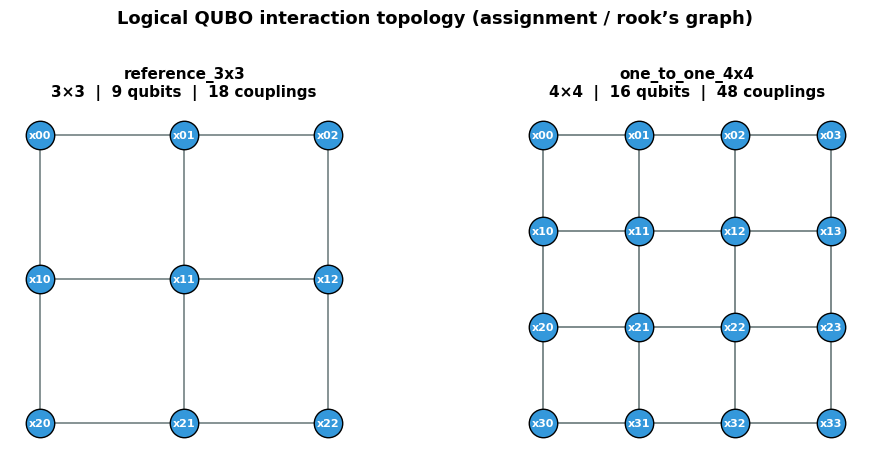

Logical graph statistics:


,instance_id,n,m,logical_qubits,logical_couplings,avg_degree
0,reference_3x3,3,3,9,18,4.0
1,one_to_one_4x4,4,4,16,48,6.0


Could not draw coupling map: plot_coupling_map() missing 1 required positional argument: 'qubit_coordinates'

Topology / transpilation overhead table:


,instance_id,algorithm,logical_qubits,depth_before,depth_after,twoq_before,twoq_after,source,depth_ratio,twoq_ratio
0,exact_capacity_4x2,standard_qaoa,8,10.0,143.0,16,63.0,transpiled,14.300000,3.937500
1,exact_capacity_4x2,gm_qaoa,8,11.0,1357.0,12,496.0,transpiled,123.363636,41.333333
2,reference_3x3,logical_qubo,9,NaN,NaN,18,NaN,logical,NaN,NaN
3,one_to_one_4x4,logical_qubo,16,NaN,NaN,48,NaN,logical,NaN,NaN
4,exact_capacity_4x2,logical_qubo,8,NaN,NaN,16,NaN,logical,NaN,NaN


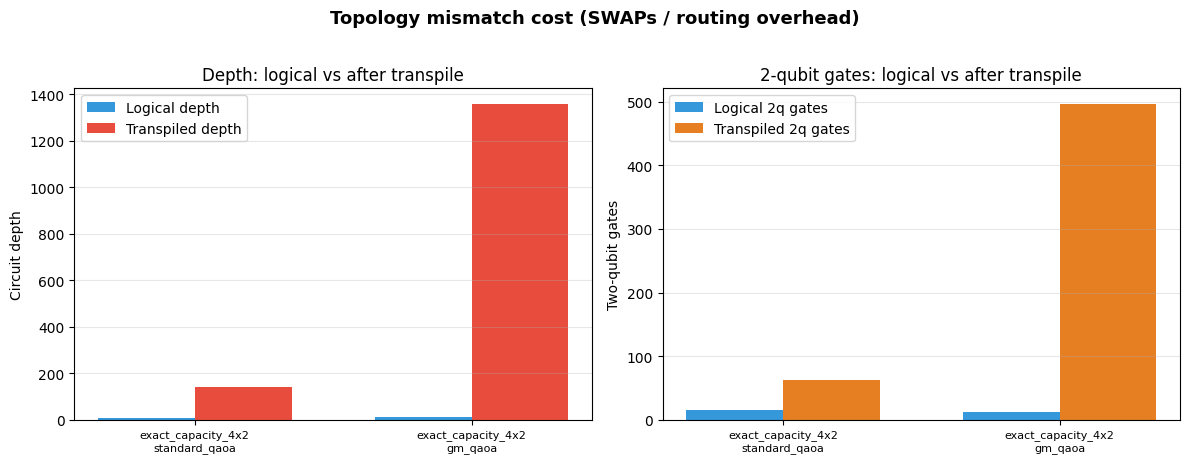


Takeaway
--------
• Logical topology = dense rook’s graph (row cliques + column cliques).
• Hardware topology = sparse heavy-hex coupling map.
• Mapping dense logical couplings onto a sparse chip forces SWAP chains.
• That is why transpiled depth and 2-qubit gate counts jump sharply as n grows
  (3×3 → 4×4 → 5×5), even though the number of physical qubits stays ≈ n·m.



In [20]:
# Notebook cell 18/36 — Analyze logical topology and hardware coupling
# Section 4.2 — Logical QUBO topology and hardware coupling analysis
# ============================================================
# Topology comparison: Logical QUBO graph vs Hardware coupling
# ============================================================
# Paste this cell near the end of the notebook (after QUBO + optional hardware).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

try:
    import networkx as nx
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "networkx", "-q"])
    import networkx as nx


def qubo_interaction_graph(instance_id: str):
    """Build the logical interaction graph from QUBO quadratic terms."""
    qubo = INSTANCE_QUBOS[instance_id]
    n = INSTANCES[instance_id].n_agents
    m = INSTANCES[instance_id].n_resources

    G = nx.Graph()
    # nodes = logical variables x_ij
    for i in range(n):
        for j in range(m):
            G.add_node((i, j), label=f"x{i}{j}", row=i, col=j)

    # quadratic couplings (upper-triangular dict or matrix-style)
    quadratic = qubo.get("quadratic", {})
    if isinstance(quadratic, dict):
        for (a, b), coeff in quadratic.items():
            if abs(float(coeff)) < 1e-12:
                continue
            # keys may be flat indices or (i,j) tuples
            def to_pair(k):
                if isinstance(k, tuple) and len(k) == 2:
                    return k
                # flat index κ = i*m + j
                k = int(k)
                return (k // m, k % m)
            u, v = to_pair(a), to_pair(b)
            if u != v:
                G.add_edge(u, v, weight=float(coeff))
    else:
        # fallback: rebuild from definition (row cliques + column cliques)
        for i in range(n):
            cols = list(range(m))
            for a in range(m):
                for b in range(a + 1, m):
                    G.add_edge((i, cols[a]), (i, cols[b]), weight=1.0)
        for j in range(m):
            for a in range(n):
                for b in range(a + 1, n):
                    G.add_edge((a, j), (b, j), weight=1.0)

    # if still no edges, force rook's graph structure
    if G.number_of_edges() == 0:
        for i in range(n):
            for a in range(m):
                for b in range(a + 1, m):
                    G.add_edge((i, a), (i, b))
        for j in range(m):
            for a in range(n):
                for b in range(a + 1, n):
                    G.add_edge((a, j), (b, j))

    return G


def draw_logical_graph(G, ax, title):
    """Draw assignment QUBO graph with grid-like layout."""
    # position nodes on a grid (row, col)
    pos = {node: (node[1], -node[0]) for node in G.nodes()}
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=420, node_color="#3498db", edgecolors="black")
    nx.draw_networkx_labels(
        G, pos, ax=ax,
        labels={n: f"x{n[0]}{n[1]}" for n in G.nodes()},
        font_size=8, font_color="white", font_weight="bold"
    )
    nx.draw_networkx_edges(G, pos, ax=ax, width=1.2, edge_color="#7f8c8d", alpha=0.85)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_aspect("equal")
    ax.axis("off")


# ----------------------------------------------------------
# 1) Logical interaction graphs for small instances
# ----------------------------------------------------------
logical_ids = [iid for iid in ["reference_3x3", "one_to_one_4x4", "one_to_one_5x5"] if iid in INSTANCES]
if not logical_ids:
    logical_ids = list(INSTANCES.keys())[:3]

fig1, axes1 = plt.subplots(1, len(logical_ids), figsize=(5.2 * len(logical_ids), 4.5))
if len(logical_ids) == 1:
    axes1 = [axes1]

graph_stats = []
for ax, iid in zip(axes1, logical_ids):
    G = qubo_interaction_graph(iid)
    n, m = INSTANCES[iid].n_agents, INSTANCES[iid].n_resources
    draw_logical_graph(
        G, ax,
        f"{iid}\n{n}×{m}  |  {G.number_of_nodes()} qubits  |  {G.number_of_edges()} couplings"
    )
    graph_stats.append({
        "instance_id": iid,
        "n": n,
        "m": m,
        "logical_qubits": G.number_of_nodes(),
        "logical_couplings": G.number_of_edges(),
        "avg_degree": float(np.mean([d for _, d in G.degree()])) if G.number_of_nodes() else 0.0,
    })

fig1.suptitle("Logical QUBO interaction topology (assignment / rook’s graph)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print("Logical graph statistics:")
display(pd.DataFrame(graph_stats))


# ----------------------------------------------------------
# 2) Hardware coupling map (if backend object exists)
# ----------------------------------------------------------
backend_obj = None
for candidate in ["target_backend", "backend", "selected_backend"]:
    if candidate in globals() and globals()[candidate] is not None:
        backend_obj = globals()[candidate]
        break

fig2 = None
if backend_obj is not None:
    try:
        from qiskit.visualization import plot_coupling_map
        cmap = backend_obj.coupling_map
        if cmap is None and hasattr(backend_obj, "configuration"):
            cmap = backend_obj.configuration().coupling_map
        num_q = getattr(backend_obj, "num_qubits", None) or backend_obj.configuration().n_qubits
        fig2 = plot_coupling_map(
            num_q,
            coupling_map=cmap,
            figsize=(8, 6),
        )
        fig2.suptitle(f"Hardware coupling map — {getattr(backend_obj, 'name', type(backend_obj).__name__)}", fontsize=12)
        plt.show()
        print(f"Hardware qubits available: {num_q}")
        if cmap is not None:
            print(f"Hardware edges (coupling links): {len(list(cmap.get_edges() if hasattr(cmap, 'get_edges') else cmap))}")
    except Exception as exc:
        print(f"Could not draw coupling map: {exc}")
else:
    print("No backend object in memory — skipping hardware coupling-map figure.")
    print("Re-run the hardware/transpile cell first if you want that panel.")


# ----------------------------------------------------------
# 3) Transpilation overhead comparison (depth & 2q gates)
# ----------------------------------------------------------
rows = []

# Prefer real transpilation metrics if present
if "transpilation_metrics" in globals() and isinstance(transpilation_metrics, pd.DataFrame) and not transpilation_metrics.empty:
    for _, r in transpilation_metrics.iterrows():
        rows.append({
            "instance_id": r.get("instance_id", HARDWARE_INSTANCE_ID if "HARDWARE_INSTANCE_ID" in globals() else "hardware"),
            "algorithm": r.get("algorithm", "standard_qaoa"),
            "logical_qubits": r.get("logical_qubits", np.nan),
            "depth_before": r.get("depth_before", np.nan),
            "depth_after": r.get("depth_after", np.nan),
            "twoq_before": r.get("two_qubit_gates_before", np.nan),
            "twoq_after": r.get("two_qubit_gates_after", np.nan),
            "source": "transpiled",
        })

# Always add theoretical logical sizes for the catalog instances
for iid, inst in INSTANCES.items():
    nq = inst.n_agents * inst.n_resources
    # rough logical 2q count for one QAOA layer of assignment QUBO:
    # row cliques: n * C(m,2)  + column cliques: m * C(n,2)
    logical_2q = inst.n_agents * (inst.n_resources * (inst.n_resources - 1) // 2) + \
                 inst.n_resources * (inst.n_agents * (inst.n_agents - 1) // 2)
    rows.append({
        "instance_id": iid,
        "algorithm": "logical_qubo",
        "logical_qubits": nq,
        "depth_before": np.nan,
        "depth_after": np.nan,
        "twoq_before": logical_2q,
        "twoq_after": np.nan,
        "source": "logical",
    })

overhead_df = pd.DataFrame(rows)
if not overhead_df.empty:
    overhead_df["depth_ratio"] = overhead_df["depth_after"] / overhead_df["depth_before"]
    overhead_df["twoq_ratio"] = overhead_df["twoq_after"] / overhead_df["twoq_before"]

print("\nTopology / transpilation overhead table:")
display(overhead_df)

# Bar plot of overhead when transpiled rows exist
tp = overhead_df[overhead_df["source"] == "transpiled"].copy()
if not tp.empty:
    fig3, axes3 = plt.subplots(1, 2, figsize=(12, 4.5))

    ax = axes3[0]
    x = np.arange(len(tp))
    w = 0.35
    ax.bar(x - w/2, tp["depth_before"].astype(float), width=w, label="Logical depth", color="#3498db")
    ax.bar(x + w/2, tp["depth_after"].astype(float), width=w, label="Transpiled depth", color="#e74c3c")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{a}\n{b}" for a, b in zip(tp["instance_id"], tp["algorithm"])], fontsize=8)
    ax.set_ylabel("Circuit depth")
    ax.set_title("Depth: logical vs after transpile")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    ax = axes3[1]
    ax.bar(x - w/2, tp["twoq_before"].astype(float), width=w, label="Logical 2q gates", color="#3498db")
    ax.bar(x + w/2, tp["twoq_after"].astype(float), width=w, label="Transpiled 2q gates", color="#e67e22")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{a}\n{b}" for a, b in zip(tp["instance_id"], tp["algorithm"])], fontsize=8)
    ax.set_ylabel("Two-qubit gates")
    ax.set_title("2-qubit gates: logical vs after transpile")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    fig3.suptitle("Topology mismatch cost (SWAPs / routing overhead)", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No transpilation_metrics found yet — depth/2q overhead bars skipped.")
    print("Run the hardware transpile cell first to populate them.")


# ----------------------------------------------------------
# 4) Short textual takeaway
# ----------------------------------------------------------
print("""
Takeaway
--------
• Logical topology = dense rook’s graph (row cliques + column cliques).
• Hardware topology = sparse heavy-hex coupling map.
• Mapping dense logical couplings onto a sparse chip forces SWAP chains.
• That is why transpiled depth and 2-qubit gate counts jump sharply as n grows
  (3×3 → 4×4 → 5×5), even though the number of physical qubits stays ≈ n·m.
""")

> **Notebook cell 19/36 — Document the simulator modes**

## 4.3 Simulator
- *Noiseless*: `AerSimulator(method="statevector")`
- *Noisy*: `FakeFez()` or any fake backend (takes a long time)

In [8]:
# Notebook cell 20/36 — Configure the ideal statevector simulator
from qiskit_aer import AerSimulator

backend = AerSimulator(method="statevector")
print("Ideal execution backend:", backend.name)


Ideal execution backend: aer_simulator_statevector


In [9]:
# Notebook cell 21/36 — Configure IBM Quantum authentication and execution controls
# Section 4.4 — IBM Quantum Runtime configuration
# IBM Quantum Runtime configuration for standard QAOA and GM-QAOA.

import getpass
import os
import warnings

from qiskit_ibm_runtime import QiskitRuntimeService

# Authentication resolution: explicit field -> environment -> Colab Secret.
# Public repository: keep this field empty and use QISKIT_IBM_TOKEN instead.
IBM_API_TOKEN = ""
IBM_INSTANCE = "auto"
IBM_BACKEND_NAME = "ibm_marrakesh"
SAVE_IBM_ACCOUNT = False

# "auto": real QPU when a token exists, otherwise a fake backend.
# "hardware": require IBM authentication. "fake": force local testing.
EXECUTION_MODE = "auto"
RUN_HARDWARE_EXECUTION = True

# Both algorithms use the same selected instance and p for a controlled comparison.
HARDWARE_INSTANCE_ID = "exact_capacity_4x2"
STANDARD_HARDWARE_P = 1
GM_HARDWARE_P = 1
HARDWARE_SHOTS = 1024
TRANSPILE_OPTIMIZATION_LEVEL = 3
TRANSPILE_SEED = 2026
SIMULATOR_SEED = 2026
ENABLE_DYNAMICAL_DECOUPLING = True
ENABLE_GATE_TWIRLING = True
MAX_EXECUTION_TIME_SECONDS = 120

# Backend-specific guardrails are evaluated after transpilation and before submission.
MAX_TRANSPILED_DEPTH = 3000
MAX_TWO_QUBIT_GATES = 5000
FORCE_HARDWARE_SUBMISSION = False

if EXECUTION_MODE not in {"auto", "hardware", "fake"}:
    raise ValueError("EXECUTION_MODE must be 'auto', 'hardware', or 'fake'.")
if HARDWARE_INSTANCE_ID not in INSTANCES:
    raise ValueError(f"Unknown HARDWARE_INSTANCE_ID: {HARDWARE_INSTANCE_ID!r}")
if STANDARD_HARDWARE_P not in (1, 2, 3):
    raise ValueError("STANDARD_HARDWARE_P must be 1, 2, or 3.")
if GM_HARDWARE_P < 1:
    raise ValueError("GM_HARDWARE_P must be positive.")


def _load_colab_secret(name: str) -> str:
    try:
        from google.colab import userdata
        return str(userdata.get(name) or "").strip()
    except Exception:
        return ""


def resolve_ibm_token(prompt: bool = False) -> str:
    """Load a token without printing it."""
    token = str(IBM_API_TOKEN or "").strip()
    if not token:
        token = os.getenv("QISKIT_IBM_TOKEN", "").strip()
    if not token:
        token = _load_colab_secret("QISKIT_IBM_TOKEN")
    if not token and prompt:
        token = getpass.getpass("IBM Quantum API key (hidden): ").strip()
    return token


def initialize_runtime_service() -> tuple[QiskitRuntimeService | None, str]:
    """Create a Runtime service or select documented local-testing mode."""
    request_hardware = EXECUTION_MODE in {"auto", "hardware"}
    token = resolve_ibm_token(prompt=EXECUTION_MODE == "hardware") if request_hardware else ""

    if token:
        if SAVE_IBM_ACCOUNT:
            QiskitRuntimeService.save_account(
                channel="ibm_quantum_platform",
                token=token,
                instance=IBM_INSTANCE,
                overwrite=True,
                set_as_default=True,
            )
            service = QiskitRuntimeService()
        else:
            service = QiskitRuntimeService(
                channel="ibm_quantum_platform",
                token=token,
                instance=IBM_INSTANCE,
            )
        return service, "ibm_hardware"

    if EXECUTION_MODE == "hardware":
        raise RuntimeError(
            "Hardware mode requires QISKIT_IBM_TOKEN in Colab Secrets, "
            "an environment variable, or the hidden prompt."
        )

    if EXECUTION_MODE == "auto":
        warnings.warn(
            "No IBM token was found. Execute All will continue with a fake IBM backend."
        )
    return None, "fake_backend"


runtime_service, target_execution_mode = initialize_runtime_service()
print("Configured execution mode:", target_execution_mode)
print("Hardware comparison instance:", HARDWARE_INSTANCE_ID)
print("Shots per circuit:", HARDWARE_SHOTS)


qiskit_runtime_service._discover_account:WARNING:2026-08-14 17:44:55,237: Loading account with the given token. A saved account will not be used.


Configured execution mode: ibm_hardware
Hardware comparison instance: exact_capacity_4x2
Shots per circuit: 1024


> **Notebook cell 22/36 — Explain the QAOA circuit architecture**

## 4.5 QAOA Circuit Architecture

QAOA is derived from the **Quantum Adiabatic Theorem**<sup>[1]</sup>, which states that if a quantum system starts in the ground state of a simple initial Hamiltonian $H_M$, slowly evolving the system towards a target Hamiltonian $H_C$ will keep it in the ground state throughout the evolution.

QAOA discretizes (trotterizes) this continuous evolution into $p$ layers, alternating between the **Cost Hamiltonian** ($H_C$) and a **Mixer Hamiltonian** ($H_M$).

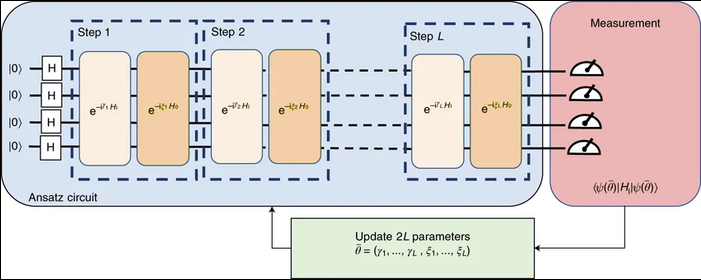 <sup>[2]</sup>

#### Circuit Breakdown (`QAOAnsatz`)

When constructed via Qiskit's `QAOAnsatz`, the circuit implements three core components automatically:

1. **Initial State Preparation ($H^{\otimes n}$):**
   - Applies Hadamard gates to $|0\rangle^{\otimes n}$ to generate an equal superposition state $|+\rangle^{\otimes n}$.
   - Mathematically, $|+\rangle^{\otimes n}$ is the exact ground state of the mixer Hamiltonian $H_M$, fulfilling the starting condition of adiabatic evolution.

2. **Cost Unitaries ($e^{-i \gamma_k H_C}$):**
   - Applies phase shifts proportional to the problem's objective function (the QUBO / Ising interactions).

3. **Mixer Unitaries ($e^{-i \beta_k H_M}$):**
   - By default, `QAOAnsatz` builds $H_M = \sum_i X_i$.
   - The mixer (or driver) operator drives quantum transitions between computational basis states, allowing the circuit to explore candidate solutions via constructive/destructive interference.

---
<sup>[1]</sup> [Quantum computing in practice](https://quantum.cloud.ibm.com/learning/en/courses/quantum-computing-in-practice/utility-scale-qaoa)

<sup>[2]</sup> [*Limitations of optimization algorithms on noisy quantum devices*. Nature Physics **17**, 1221–1227 (2021)](https://www.nature.com/articles/s41567-021-01356-3)

In [10]:
# Notebook cell 23/36 — Implement the standard-QAOA optimizer and evaluator
from scipy.optimize import minimize
from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import Statevector


def run_qaoa(
    ansatz: QAOAAnsatz,
    cost_operator: SparsePauliOp,
    initial_parameters: np.ndarray,
    maxiter: int = 100,
    shots: int = 4096,
    seed: int = 2026,
) -> dict:
    """Optimize and sample one QAOA circuit in ideal statevector simulation."""
    parameters = list(ansatz.parameters)
    initial_parameters = np.asarray(initial_parameters, dtype=float)
    if initial_parameters.size != len(parameters):
        raise ValueError(
            f"Expected {len(parameters)} parameters; received {initial_parameters.size}."
        )

    energy_history = []
    start = time.perf_counter()

    def objective(values: np.ndarray) -> float:
        circuit = ansatz.assign_parameters(dict(zip(parameters, values)))
        state = Statevector.from_instruction(circuit)
        energy = float(np.real(state.expectation_value(cost_operator)))
        energy_history.append(energy)
        return energy

    optimization = minimize(
        objective,
        initial_parameters,
        method="COBYLA",
        options={"maxiter": int(maxiter)},
    )
    optimization_runtime_s = time.perf_counter() - start

    final_circuit = ansatz.assign_parameters(dict(zip(parameters, optimization.x)))
    final_state = Statevector.from_instruction(final_circuit)
    exact_probabilities = np.asarray(final_state.probabilities(), dtype=float)

    rng = np.random.default_rng(seed)
    sampled_counts = rng.multinomial(int(shots), exact_probabilities)
    counts = {
        format(index, f"0{ansatz.num_qubits}b"): int(count)
        for index, count in enumerate(sampled_counts)
        if count > 0
    }
    sorted_probabilities = sorted(
        ((bitstring, count / shots) for bitstring, count in counts.items()),
        key=lambda item: item[1],
        reverse=True,
    )

    return {
        "optimization": optimization,
        "final_circuit": final_circuit,
        "final_state": final_state,
        "exact_probability_array": exact_probabilities,
        "energy_history": energy_history,
        "counts": counts,
        "probabilities": sorted_probabilities,
        "shots": int(shots),
        "runtime_s": float(optimization_runtime_s),
        "optimal_parameters": np.asarray(optimization.x, dtype=float),
    }


> **Notebook cell 24/36 — Document deterministic parameter initialization**

## 4.6 Parameter Initialization
**TQA Schedule:** For finite layers $p$, initializing parameters with a linear Trotterized Quantum Annealing (TQA) schedule ($\beta \to 0$, $\gamma \to 1$) explicitly guides this discrete layer-by-layer sequence to mimic continuous adiabatic trajectories.

In [11]:
# Notebook cell 25/36 — Configure the fixed depth experiments
import re


FIXED_P = 1
QAOA_DEPTHS = (1, 2, 3)
QAOA_SHOTS = 4096
QAOA_MAXITER = {1: 60, 2: 60, 3: 60}
REFERENCE_FIXED_MAXITER = 100


def get_tqa_initial_params(ansatz: QAOAAnsatz) -> np.ndarray:
    """Return one deterministic TQA-style initialization in Qiskit's parameter order."""
    p = int(ansatz.reps)
    gamma_schedule = np.linspace(0.1, 0.7, p, dtype=float)
    beta_schedule = np.linspace(0.7, 0.1, p, dtype=float)

    values = []
    for parameter in ansatz.parameters:
        name = str(parameter)
        match = re.search(r"\[(\d+)\]", name)
        index = int(match.group(1)) if match else 0
        if name.startswith("β"):
            values.append(beta_schedule[min(index, p - 1)])
        elif name.startswith("γ"):
            values.append(gamma_schedule[min(index, p - 1)])
        else:
            values.append(0.5)
    return np.asarray(values, dtype=float)


> **Notebook cell 26/36 — Define the standard-QAOA depth-sweep protocol**

## 4.7 Standard-QAOA Depth Experiments
Runs one deterministic ideal experiment for each $p\in\{1,2,3\}$.

Standard-QAOA ideal depth sweep:


,instance_id,p,optimized_expected_qubo_energy,feasible_probability,optimal_probability,best_sampled_feasible_score,classical_optimal_score,absolute_optimization_gap,ideal_circuit_depth,runtime_s
0,reference_3x3,1,39.226215,0.003583,0.000740,2.70,2.70,0.00,21,1.676498
1,reference_3x3,2,15.257437,0.089024,0.021687,2.70,2.70,0.00,41,1.119079
2,reference_3x3,3,21.386914,0.118618,0.041527,2.70,2.70,0.00,61,1.650187
3,one_to_one_4x4,1,42.062530,0.002523,0.000029,2.80,3.08,0.28,33,12.776456
4,one_to_one_4x4,2,83.253245,0.039986,0.001629,3.08,3.08,0.00,59,15.722948
5,one_to_one_4x4,3,87.475826,0.000978,0.000092,2.80,3.08,0.28,85,16.660130
6,exact_capacity_4x2,1,18.344321,0.091582,0.023380,3.25,3.25,0.00,21,0.297405
7,exact_capacity_4x2,2,8.953983,0.348893,0.054127,3.25,3.25,0.00,38,0.358492
8,exact_capacity_4x2,3,7.934315,0.439911,0.061093,3.25,3.25,0.00,55,0.452604


Original reference 3x3, p=1 candidates:


,bitstring,count,probability,qubo_energy,score,feasible,assignment_matrix
0,100010001,3,0.000732,-2.70,2.70,True,"[[1, 0, 0], [0, 1, 0], [0, 0, 1]]"
1,010100001,1,0.000244,-1.75,1.75,True,"[[1, 0, 0], [0, 0, 1], [0, 1, 0]]"
2,001010100,1,0.000244,-1.70,1.70,True,"[[0, 0, 1], [0, 1, 0], [1, 0, 0]]"
3,001100010,3,0.000732,-1.15,1.15,True,"[[0, 1, 0], [0, 0, 1], [1, 0, 0]]"
4,010001100,4,0.000977,-1.05,1.05,True,"[[0, 0, 1], [1, 0, 0], [0, 1, 0]]"
5,100100001,3,0.000732,6.20,2.35,False,"[[1, 0, 0], [0, 0, 1], [0, 0, 1]]"
6,001010001,8,0.001953,6.35,2.20,False,"[[1, 0, 0], [0, 1, 0], [1, 0, 0]]"
7,100010100,1,0.000244,6.35,2.20,False,"[[0, 0, 1], [0, 1, 0], [0, 0, 1]]"
8,100001001,1,0.000244,6.40,2.15,False,"[[1, 0, 0], [1, 0, 0], [0, 0, 1]]"
9,010010001,3,0.000732,6.45,2.10,False,"[[1, 0, 0], [0, 1, 0], [0, 1, 0]]"


,fixed_p,feasible,exact_match,qaoa_score,classical_score,score_gap,best_probability,shots
0,1,True,True,2.7,2.7,0.0,0.000732,4096


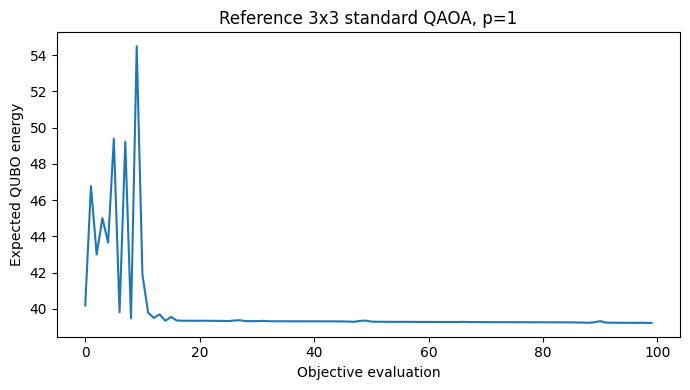

In [12]:
# Notebook cell 27/36 — Run and analyze the depth experiments
import matplotlib.pyplot as plt


def build_basis_analysis_cache(instance: AssignmentInstance) -> dict:
    """Vectorize score, energy, and feasibility over the computational basis."""
    num_qubits = instance.n_agents * instance.n_resources
    indices = np.arange(2 ** num_qubits, dtype=np.uint64)
    bits = ((indices[:, None] >> np.arange(num_qubits, dtype=np.uint64)) & 1).astype(np.int8)
    matrices = bits.reshape((-1, instance.n_agents, instance.n_resources))

    scores = np.einsum("bij,ij->b", matrices, instance.affinity, optimize=True)
    row_sums = matrices.sum(axis=2)
    column_sums = matrices.sum(axis=1)
    row_ok = np.all(row_sums == 1, axis=1)
    if instance.constraint_mode == "one_to_one":
        resource_ok = np.all(column_sums <= 1, axis=1)
    else:
        resource_ok = np.all(column_sums == instance.capacities[None, :], axis=1)
    feasible = row_ok & resource_ok

    qubo = INSTANCE_QUBOS[instance.instance_id]
    agent_penalty = qubo["lambda_A"] * np.sum((row_sums - 1) ** 2, axis=1)
    if instance.constraint_mode == "one_to_one":
        resource_penalty = qubo["lambda_R"] * np.sum(
            column_sums * (column_sums - 1) / 2.0,
            axis=1,
        )
    else:
        resource_penalty = qubo["lambda_R"] * np.sum(
            (column_sums - instance.capacities[None, :]) ** 2,
            axis=1,
        )
    energies = -scores + agent_penalty + resource_penalty
    optimal_score = optimal_score_by_instance[instance.instance_id]
    optimal_mask = feasible & np.isclose(scores, optimal_score)

    return {
        "bits": bits,
        "scores": scores.astype(float),
        "energies": energies.astype(float),
        "feasible": feasible,
        "optimal_mask": optimal_mask,
        "optimal_score": float(optimal_score),
    }


def analyze_qaoa_run(
    instance: AssignmentInstance,
    p: int,
    qaoa_run: dict,
    cache: dict,
) -> tuple[dict, pd.DataFrame]:
    probabilities = qaoa_run["exact_probability_array"]
    feasible_probability = float(probabilities[cache["feasible"]].sum())
    optimal_probability = float(probabilities[cache["optimal_mask"]].sum())
    expected_score = float(np.dot(probabilities, cache["scores"]))
    expected_qubo_energy = float(np.dot(probabilities, cache["energies"]))

    candidate_rows = []
    for bitstring, count in qaoa_run["counts"].items():
        basis_index = int(bitstring, 2)
        X_candidate = cache["bits"][basis_index].reshape(instance.affinity.shape)
        candidate_rows.append({
            "bitstring": bitstring,
            "count": int(count),
            "probability": float(count / qaoa_run["shots"]),
            "qubo_energy": float(cache["energies"][basis_index]),
            "score": float(cache["scores"][basis_index]),
            "feasible": bool(cache["feasible"][basis_index]),
            "assignment_matrix": X_candidate.astype(int),
        })

    candidates = pd.DataFrame(candidate_rows).sort_values(
        ["feasible", "qubo_energy", "probability"],
        ascending=[False, True, False],
    ).reset_index(drop=True)
    feasible_candidates = candidates[candidates["feasible"]]

    if feasible_candidates.empty:
        best_score = np.nan
        best_energy = np.nan
        score_gap = np.nan
        best_bitstring = None
    else:
        best_row = feasible_candidates.sort_values(
            ["score", "probability"],
            ascending=[False, False],
        ).iloc[0]
        best_score = float(best_row["score"])
        best_energy = float(best_row["qubo_energy"])
        score_gap = float(cache["optimal_score"] - best_score)
        best_bitstring = str(best_row["bitstring"])

    absolute_gap = float(score_gap) if np.isfinite(score_gap) else np.nan
    relative_gap = (
        absolute_gap / (abs(cache["optimal_score"]) + 1e-12)
        if np.isfinite(absolute_gap)
        else np.nan
    )

    summary = {
        "instance_id": instance.instance_id,
        "n_agents": instance.n_agents,
        "n_resources": instance.n_resources,
        "constraint_mode": instance.constraint_mode,
        "capacities": instance.capacities.tolist(),
        "p": int(p),
        "shots": int(qaoa_run["shots"]),
        "optimizer": "COBYLA",
        "maxiter": int(qaoa_run["maxiter"]),
        "optimization_success": bool(qaoa_run["optimization"].success),
        "optimization_status": int(qaoa_run["optimization"].status),
        "optimization_message": str(qaoa_run["optimization"].message),
        "optimized_expected_qubo_energy": expected_qubo_energy,
        "expected_score": expected_score,
        "feasible_probability": feasible_probability,
        "optimal_probability": optimal_probability,
        "best_sampled_feasible_bitstring": best_bitstring,
        "best_sampled_feasible_score": best_score,
        "best_sampled_feasible_qubo_energy": best_energy,
        "classical_optimal_score": float(cache["optimal_score"]),
        "absolute_optimization_gap": absolute_gap,
        "relative_optimization_gap": float(relative_gap),
        "ideal_circuit_depth": int(qaoa_run["final_circuit"].decompose(reps=2).depth()),
        "runtime_s": float(qaoa_run["runtime_s"]),
        "optimal_parameters": qaoa_run["optimal_parameters"].tolist(),
    }
    return summary, candidates


BASIS_ANALYSIS = {
    instance_id: build_basis_analysis_cache(instance)
    for instance_id, instance in INSTANCES.items()
}

qaoa_results_by_key = {}
qaoa_summary_rows = []

for instance_index, instance in enumerate(INSTANCES.values()):
    cost_operator = INSTANCE_QUBOS[instance.instance_id]["cost_operator"]
    for p in QAOA_DEPTHS:
        ansatz_local = QAOAAnsatz(
            cost_operator=cost_operator,
            reps=p,
            flatten=True,
        )
        preserve_original_reference = (
            instance.instance_id == REFERENCE_INSTANCE_ID and p == FIXED_P
        )
        initial_local = (
            np.ones(ansatz_local.num_parameters, dtype=float)
            if preserve_original_reference
            else get_tqa_initial_params(ansatz_local)
        )
        maxiter_local = (
            REFERENCE_FIXED_MAXITER
            if preserve_original_reference
            else QAOA_MAXITER[p]
        )
        run_local = run_qaoa(
            ansatz=ansatz_local,
            cost_operator=cost_operator,
            initial_parameters=initial_local,
            maxiter=maxiter_local,
            shots=QAOA_SHOTS,
            seed=2026,
        )
        run_local["maxiter"] = int(maxiter_local)
        summary_local, candidates_local = analyze_qaoa_run(
            instance,
            p,
            run_local,
            BASIS_ANALYSIS[instance.instance_id],
        )
        run_local["summary"] = summary_local
        run_local["candidates"] = candidates_local
        run_local["ansatz"] = ansatz_local
        qaoa_results_by_key[(instance.instance_id, p)] = run_local
        qaoa_summary_rows.append(summary_local)

qaoa_depth_sweep_results = pd.DataFrame(qaoa_summary_rows)
print("Standard-QAOA ideal depth sweep:")
display(qaoa_depth_sweep_results[
    [
        "instance_id",
        "p",
        "optimized_expected_qubo_energy",
        "feasible_probability",
        "optimal_probability",
        "best_sampled_feasible_score",
        "classical_optimal_score",
        "absolute_optimization_gap",
        "ideal_circuit_depth",
        "runtime_s",
    ]
])

# Preserve the original 3x3, p=1 experiment and aliases.
reference_qaoa_run = qaoa_results_by_key[(REFERENCE_INSTANCE_ID, FIXED_P)]
qaoa_ansatz = reference_qaoa_run["ansatz"]
initial_parameters = np.ones(qaoa_ansatz.num_parameters, dtype=float)
qaoa_result = reference_qaoa_run
qaoa_candidates = reference_qaoa_run["candidates"]
best_qaoa_row = qaoa_candidates[qaoa_candidates["feasible"]].iloc[0]
qaoa_comparison = {
    "fixed_p": FIXED_P,
    "feasible": bool(best_qaoa_row["feasible"]),
    "exact_match": bool(
        np.isclose(best_qaoa_row["score"], exact_result["score"])
    ),
    "qaoa_score": float(best_qaoa_row["score"]),
    "classical_score": float(exact_result["score"]),
    "score_gap": float(exact_result["score"] - best_qaoa_row["score"]),
    "best_probability": float(best_qaoa_row["probability"]),
    "shots": int(reference_qaoa_run["shots"]),
}

print("Original reference 3x3, p=1 candidates:")
display(qaoa_candidates.head(20))
display(pd.DataFrame([qaoa_comparison]))

plt.figure(figsize=(7, 4))
plt.plot(reference_qaoa_run["energy_history"])
plt.xlabel("Objective evaluation")
plt.ylabel("Expected QUBO energy")
plt.title("Reference 3x3 standard QAOA, p=1")
plt.tight_layout()
plt.show()


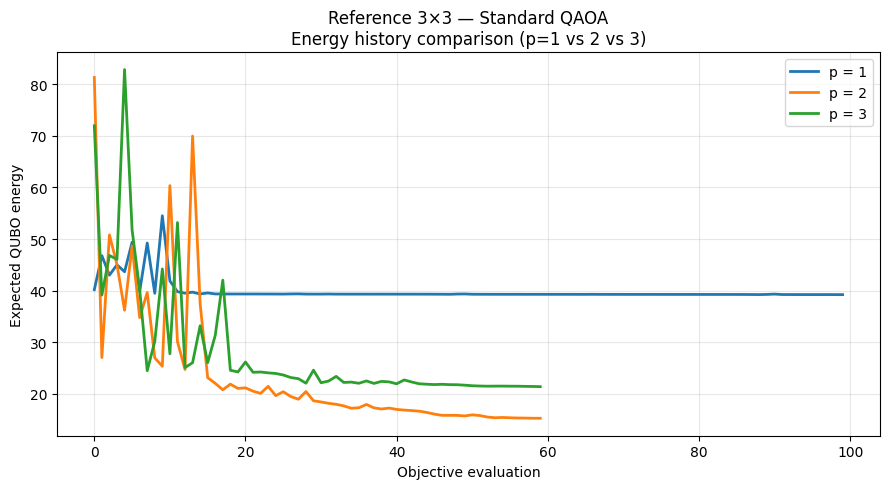

In [19]:
# Notebook cell 28/36 — Plot the standard-QAOA optimization histories
# --- Energy history p=1 vs p=2 vs p=3 (reference 3x3) ---
plt.figure(figsize=(9, 5))

for p in [1, 2, 3]:
    history = qaoa_results_by_key[("reference_3x3", p)]["energy_history"]
    plt.plot(history, label=f"p = {p}", linewidth=2)

plt.xlabel("Objective evaluation")
plt.ylabel("Expected QUBO energy")
plt.title("Reference 3×3 — Standard QAOA\nEnergy history comparison (p=1 vs 2 vs 3)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("phase1_reference_3x3_energy_history_p1_p2_p3.png", dpi=180, bbox_inches="tight")
plt.show()

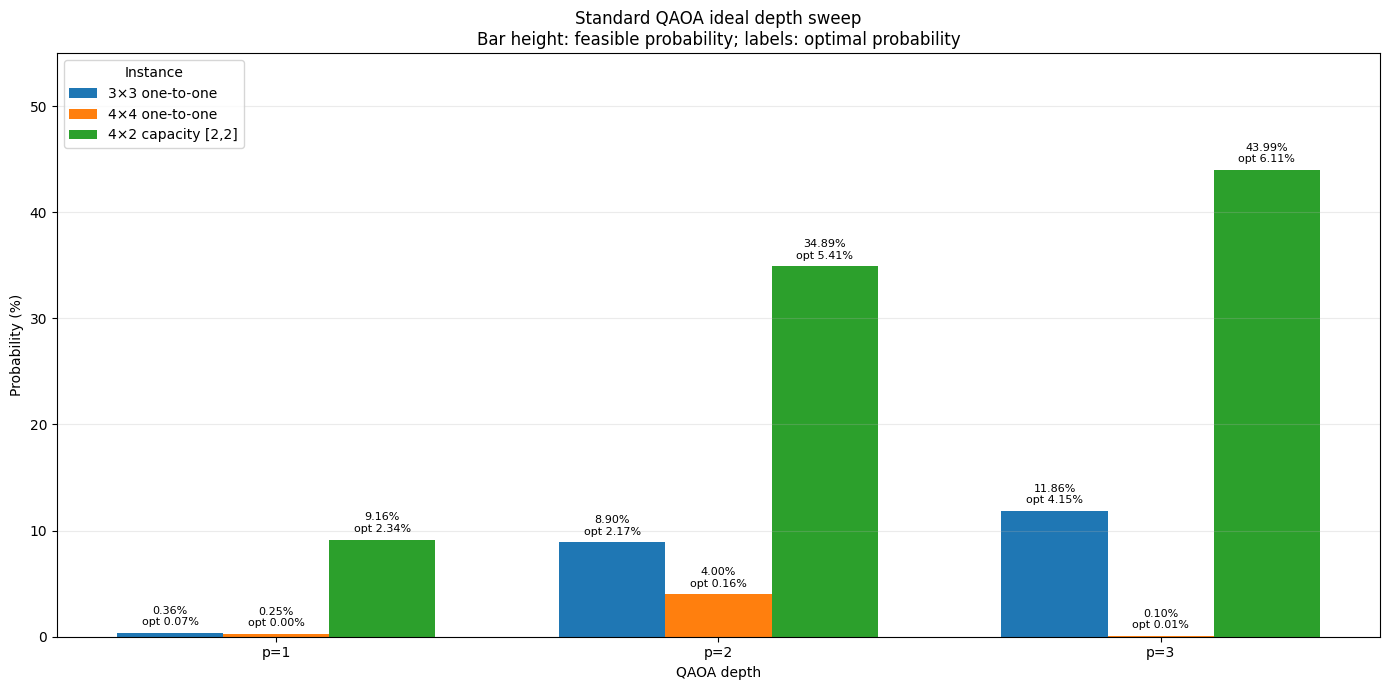

Saved: phase1_standard_qaoa_depth_probabilities.png


In [13]:
# Notebook cell 29/36 — Plot the standard-QAOA depth comparison
# Phase-1 visualization: Standard-QAOA depth comparison on the ideal simulator.

import matplotlib.pyplot as plt
import numpy as np


_DEPTH_INSTANCE_LABELS = {
    "reference_3x3": "3×3 one-to-one",
    "one_to_one_4x4": "4×4 one-to-one",
    "exact_capacity_4x2": "4×2 capacity [2,2]",
}
_depth_instance_order = [
    instance_id
    for instance_id in INSTANCES
    if instance_id in set(qaoa_depth_sweep_results["instance_id"])
]
_depth_values = np.asarray(sorted(qaoa_depth_sweep_results["p"].unique()), dtype=float)

if tuple(int(value) for value in _depth_values) != (1, 2, 3):
    raise RuntimeError(
        "The Phase-1 depth visualization expects the exact sweep p in {1, 2, 3}."
    )

_depth_bar_width = 0.24
_depth_figure, _depth_axis = plt.subplots(figsize=(14, 7))

for _instance_offset, _instance_id in enumerate(_depth_instance_order):
    _instance_rows = (
        qaoa_depth_sweep_results.loc[
            qaoa_depth_sweep_results["instance_id"] == _instance_id
        ]
        .set_index("p")
        .reindex(_depth_values.astype(int))
    )
    _x_positions = _depth_values + (
        _instance_offset - (len(_depth_instance_order) - 1) / 2.0
    ) * _depth_bar_width
    _feasible_percent = (
        100.0 * _instance_rows["feasible_probability"].to_numpy(dtype=float)
    )
    _optimal_percent = (
        100.0 * _instance_rows["optimal_probability"].to_numpy(dtype=float)
    )

    _bars = _depth_axis.bar(
        _x_positions,
        _feasible_percent,
        width=_depth_bar_width,
        label=_DEPTH_INSTANCE_LABELS.get(_instance_id, _instance_id),
    )

    for _bar, _optimal_value in zip(_bars, _optimal_percent):
        _feasible_value = float(_bar.get_height())
        _depth_axis.annotate(
            f"{_feasible_value:.2f}%\nopt {_optimal_value:.2f}%",
            xy=(
                _bar.get_x() + _bar.get_width() / 2.0,
                _feasible_value,
            ),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
        )

_depth_axis.set_xticks(_depth_values)
_depth_axis.set_xticklabels([f"p={int(value)}" for value in _depth_values])
_depth_axis.set_xlabel("QAOA depth")
_depth_axis.set_ylabel("Probability (%)")
_depth_axis.set_title(
    "Standard QAOA ideal depth sweep\n"
    "Bar height: feasible probability; labels: optimal probability"
)
_depth_axis.grid(axis="y", alpha=0.25)
_depth_axis.legend(title="Instance", loc="upper left")

_depth_maximum = float(
    100.0 * qaoa_depth_sweep_results["feasible_probability"].max()
)
_depth_axis.set_ylim(0.0, max(1.0, 1.25 * _depth_maximum))
_depth_figure.tight_layout()

QAOA_DEPTH_COMPARISON_FIGURE_PATH = (
    "phase1_standard_qaoa_depth_probabilities.png"
)
_depth_figure.savefig(
    QAOA_DEPTH_COMPARISON_FIGURE_PATH,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

print("Saved:", QAOA_DEPTH_COMPARISON_FIGURE_PATH)


> **Notebook cell 30/36 — Introduce Grover-Mixer QAOA**

# 5. Grover-Mixer QAOA (GM-QAOA)


In [14]:
# Notebook cell 31/36 — Build and validate the GM-QAOA implementation
from qiskit import QuantumCircuit
from qiskit.circuit.library import MCPhaseGate, StatePreparation
from qiskit.quantum_info import Statevector, state_fidelity


GM_DEPTHS = (1,)
GM_MAXITER = 100


def enumerate_feasible_assignments(instance: AssignmentInstance) -> list[np.ndarray]:
    matrices = []
    if instance.constraint_mode == "one_to_one":
        assignments = itertools.permutations(
            range(instance.n_resources),
            instance.n_agents,
        )
    else:
        assignments = (
            assignment
            for assignment in itertools.product(
                range(instance.n_resources),
                repeat=instance.n_agents,
            )
            if np.array_equal(
                np.bincount(assignment, minlength=instance.n_resources),
                instance.capacities,
            )
        )

    for assignment in assignments:
        X = np.zeros(instance.affinity.shape, dtype=int)
        X[np.arange(instance.n_agents), np.asarray(assignment, dtype=int)] = 1
        matrices.append(X)
    return matrices


def gm_qaoa_feasible_state(
    feasible_energies: np.ndarray,
    betas: np.ndarray,
    gammas: np.ndarray,
) -> np.ndarray:
    num_feasible = int(len(feasible_energies))
    amplitudes = np.ones(num_feasible, dtype=complex) / np.sqrt(num_feasible)
    for beta, gamma in zip(betas, gammas):
        amplitudes *= np.exp(-1j * float(gamma) * feasible_energies)
        amplitudes -= (
            1.0 - np.exp(-1j * float(beta))
        ) * np.mean(amplitudes)
    return amplitudes


def optimize_gm_qaoa(instance: AssignmentInstance, p: int = 1) -> dict:
    feasible_matrices = enumerate_feasible_assignments(instance)
    feasible_indices = np.asarray([
        bitvector_to_basis_index(X.reshape(-1))
        for X in feasible_matrices
    ], dtype=int)
    feasible_scores = np.asarray([
        score_assignment(instance.affinity, X)
        for X in feasible_matrices
    ], dtype=float)
    feasible_energies = -feasible_scores

    def objective(parameters: np.ndarray) -> float:
        parameters = np.asarray(parameters, dtype=float)
        betas = parameters[:p]
        gammas = parameters[p:]
        probabilities = np.abs(
            gm_qaoa_feasible_state(feasible_energies, betas, gammas)
        ) ** 2
        return float(np.dot(probabilities, feasible_energies))

    initial = np.concatenate((
        np.linspace(0.85, 0.15, p, dtype=float),
        np.linspace(0.15, 0.85, p, dtype=float),
    ))
    if p == 1:
        initial[:] = 1.0

    start = time.perf_counter()
    optimization = minimize(
        objective,
        initial,
        method="COBYLA",
        options={"maxiter": GM_MAXITER},
    )
    runtime_s = time.perf_counter() - start
    betas = np.asarray(optimization.x[:p], dtype=float)
    gammas = np.asarray(optimization.x[p:], dtype=float)
    amplitudes = gm_qaoa_feasible_state(
        feasible_energies,
        betas,
        gammas,
    )
    probabilities = np.abs(amplitudes) ** 2

    optimal_score = optimal_score_by_instance[instance.instance_id]
    optimal_probability = float(
        probabilities[np.isclose(feasible_scores, optimal_score)].sum()
    )
    supported = feasible_scores[probabilities > 1e-14]
    best_score = float(supported.max()) if supported.size else np.nan

    return {
        "instance_id": instance.instance_id,
        "p": int(p),
        "optimization": optimization,
        "betas": betas,
        "gammas": gammas,
        "feasible_matrices": feasible_matrices,
        "feasible_indices": feasible_indices,
        "feasible_scores": feasible_scores,
        "feasible_energies": feasible_energies,
        "amplitudes": amplitudes,
        "probabilities": probabilities,
        "feasible_probability": float(probabilities.sum()),
        "optimal_probability": optimal_probability,
        "best_score": best_score,
        "classical_score": float(optimal_score),
        "score_gap": float(optimal_score - best_score),
        "runtime_s": float(runtime_s),
    }


def _one_hot_state(width: int, allowed_columns) -> StatePreparation:
    amplitudes = np.zeros(2 ** width, dtype=complex)
    allowed_columns = tuple(int(column) for column in allowed_columns)
    amplitudes[[1 << column for column in allowed_columns]] = (
        1.0 / np.sqrt(len(allowed_columns))
    )
    return StatePreparation(amplitudes)


def build_permutation_state_preparation(n_size: int) -> QuantumCircuit:
    num_qubits = n_size * n_size
    circuit = QuantumCircuit(num_qubits, name=f"U_S_perm_{n_size}")

    first_row = list(range(n_size))
    circuit.append(_one_hot_state(n_size, range(n_size)), first_row)

    for row in range(1, n_size - 1):
        for chosen_prefix in itertools.permutations(range(n_size), row):
            remaining = [column for column in range(n_size) if column not in chosen_prefix]
            controls = [previous_row * n_size + chosen_prefix[previous_row] for previous_row in range(row)]
            targets = [row * n_size + column for column in range(n_size)]
            controlled_preparation = _one_hot_state(n_size, remaining).control(len(controls))
            circuit.append(controlled_preparation, controls + targets)

    last_row = n_size - 1
    for column in range(n_size):
        target = last_row * n_size + column
        circuit.x(target)
        for row in range(last_row):
            circuit.cx(row * n_size + column, target)
    return circuit


def build_exact_capacity_4x2_state_preparation(capacities: np.ndarray) -> QuantumCircuit:
    if not np.array_equal(np.asarray(capacities, dtype=int), np.array([2, 2])):
        raise ValueError("This fixed 4x2 preparation requires capacities [2, 2].")
    circuit = QuantumCircuit(8, name="U_S_cap_4x2")
    resource_zero_qubits = [0, 2, 4, 6]
    amplitudes = np.zeros(2 ** len(resource_zero_qubits), dtype=complex)
    weight_two_indices = [
        index
        for index in range(2 ** len(resource_zero_qubits))
        if int(index).bit_count() == 2
    ]
    amplitudes[weight_two_indices] = 1.0 / np.sqrt(len(weight_two_indices))
    circuit.append(StatePreparation(amplitudes), resource_zero_qubits)
    for agent in range(4):
        resource_zero = 2 * agent
        resource_one = resource_zero + 1
        circuit.x(resource_one)
        circuit.cx(resource_zero, resource_one)
    return circuit


def build_feasible_state_preparation(instance: AssignmentInstance) -> QuantumCircuit:
    if (
        instance.constraint_mode == "one_to_one"
        and instance.n_agents == instance.n_resources
        and instance.n_agents in {3, 4}
    ):
        return build_permutation_state_preparation(instance.n_agents)
    if (
        instance.instance_id == "exact_capacity_4x2"
        and instance.affinity.shape == (4, 2)
    ):
        return build_exact_capacity_4x2_state_preparation(instance.capacities)
    raise NotImplementedError(
        "Hardware state preparation is implemented only for the three fixed Phase-1 instances."
    )


def build_gm_qaoa_circuit(
    instance: AssignmentInstance,
    betas: np.ndarray,
    gammas: np.ndarray,
) -> QuantumCircuit:
    betas = np.asarray(betas, dtype=float).reshape(-1)
    gammas = np.asarray(gammas, dtype=float).reshape(-1)
    if betas.size != gammas.size:
        raise ValueError("betas and gammas must have the same length.")

    num_qubits = instance.n_agents * instance.n_resources
    state_preparation = build_feasible_state_preparation(instance)
    circuit = QuantumCircuit(num_qubits, name=f"GM_QAOA_{instance.instance_id}")
    circuit.compose(state_preparation, inplace=True)

    for beta, gamma in zip(betas, gammas):
        for qubit, affinity in enumerate(instance.affinity.reshape(-1)):
            circuit.p(float(gamma) * float(affinity), qubit)
        circuit.compose(state_preparation.inverse(), inplace=True)
        circuit.x(range(num_qubits))
        if num_qubits == 1:
            circuit.p(-float(beta), 0)
        else:
            circuit.append(
                MCPhaseGate(-float(beta), num_ctrl_qubits=num_qubits - 1),
                range(num_qubits),
            )
        circuit.x(range(num_qubits))
        circuit.compose(state_preparation, inplace=True)

    return circuit


gm_ideal_results_by_key = {}
gm_summary_rows = []

gm_instance_order = list(INSTANCES.values())
for instance in gm_instance_order:
    for p in GM_DEPTHS:
        gm_run = optimize_gm_qaoa(instance, p=p)
        U_S_local = build_feasible_state_preparation(instance)
        prepared_state = Statevector.from_instruction(U_S_local)
        expected_initial = np.zeros(2 ** U_S_local.num_qubits, dtype=complex)
        expected_initial[gm_run["feasible_indices"]] = 1.0 / np.sqrt(
            len(gm_run["feasible_indices"])
        )
        initial_fidelity = float(
            state_fidelity(prepared_state, Statevector(expected_initial))
        )
        assert np.isclose(initial_fidelity, 1.0, atol=1e-9)

        circuit_local = build_gm_qaoa_circuit(
            instance,
            gm_run["betas"],
            gm_run["gammas"],
        )
        state_local = Statevector.from_instruction(circuit_local)
        expected_final = np.zeros(2 ** circuit_local.num_qubits, dtype=complex)
        expected_final[gm_run["feasible_indices"]] = gm_run["amplitudes"]
        circuit_fidelity = float(
            state_fidelity(state_local, Statevector(expected_final))
        )
        assert np.isclose(circuit_fidelity, 1.0, atol=1e-8)

        result_rows = pd.DataFrame([
            {
                "bitstring": format(index, f"0{circuit_local.num_qubits}b"),
                "probability": float(probability),
                "score": float(score),
                "assignment_matrix": X,
            }
            for X, index, probability, score in zip(
                gm_run["feasible_matrices"],
                gm_run["feasible_indices"],
                gm_run["probabilities"],
                gm_run["feasible_scores"],
            )
        ]).sort_values(
            ["score", "probability"],
            ascending=[False, False],
        ).reset_index(drop=True)

        gm_run.update({
            "state_preparation": U_S_local,
            "circuit": circuit_local,
            "state": state_local,
            "results_table": result_rows,
            "initial_state_fidelity": initial_fidelity,
            "circuit_fidelity": circuit_fidelity,
        })
        gm_ideal_results_by_key[(instance.instance_id, p)] = gm_run
        gm_summary_rows.append({
            "instance_id": instance.instance_id,
            "n_agents": instance.n_agents,
            "n_resources": instance.n_resources,
            "constraint_mode": instance.constraint_mode,
            "capacities": instance.capacities.tolist(),
            "p": p,
            "feasible_probability": gm_run["feasible_probability"],
            "optimal_probability": gm_run["optimal_probability"],
            "best_score": gm_run["best_score"],
            "classical_score": gm_run["classical_score"],
            "score_gap": gm_run["score_gap"],
            "initial_state_fidelity": initial_fidelity,
            "circuit_fidelity": circuit_fidelity,
            "ideal_circuit_depth": int(circuit_local.decompose(reps=2).depth()),
            "runtime_s": gm_run["runtime_s"],
            "betas": gm_run["betas"].tolist(),
            "gammas": gm_run["gammas"].tolist(),
        })

gm_ideal_summary = pd.DataFrame(gm_summary_rows)
print("GM-QAOA ideal results:")
display(gm_ideal_summary)

# Preserve the original reference aliases.
reference_gm_run = gm_ideal_results_by_key[(REFERENCE_INSTANCE_ID, 1)]
feasible_matrices = reference_gm_run["feasible_matrices"]
feasible_indices = reference_gm_run["feasible_indices"]
feasible_scores = reference_gm_run["feasible_scores"]
feasible_energies = reference_gm_run["feasible_energies"]
num_qubits = n * m
num_feasible = len(feasible_indices)
U_S = reference_gm_run["state_preparation"]
gm_beta = float(reference_gm_run["betas"][0])
gm_gamma = float(reference_gm_run["gammas"][0])
gm_circuit = reference_gm_run["circuit"]
gm_state = reference_gm_run["state"]
gm_probabilities = gm_state.probabilities()
gm_feasible_probability = float(gm_probabilities[feasible_indices].sum())
assert np.isclose(gm_feasible_probability, 1.0, atol=1e-10)
gm_results = reference_gm_run["results_table"]
gm_qaoa_summary = {
    "fixed_p": 1,
    "feasible_probability": gm_feasible_probability,
    "best_score": reference_gm_run["best_score"],
    "classical_score": reference_gm_run["classical_score"],
    "score_gap": reference_gm_run["score_gap"],
    "optimal_probability": reference_gm_run["optimal_probability"],
    "circuit_depth": int(gm_circuit.decompose(reps=2).depth()),
}
display(gm_results[["bitstring", "probability", "score"]])
display(pd.DataFrame([gm_qaoa_summary]))


GM-QAOA ideal results:


,instance_id,n_agents,n_resources,constraint_mode,capacities,p,feasible_probability,optimal_probability,best_score,classical_score,score_gap,initial_state_fidelity,circuit_fidelity,ideal_circuit_depth,runtime_s,betas,gammas
0,reference_3x3,3,3,one_to_one,"[1, 1, 1]",1,1.0,0.692281,2.70,2.70,0.0,1.0,1.0,1062,0.068595,[4.122864834208651],[1.7176720969733803]
1,one_to_one_4x4,4,4,one_to_one,"[1, 1, 1, 1]",1,1.0,0.107441,3.08,3.08,0.0,1.0,1.0,20252,0.059578,[1.3448072899011083],[-1.5697552330239946]
2,exact_capacity_4x2,4,2,exact_capacity,"[2, 2]",1,1.0,0.503666,3.25,3.25,0.0,1.0,1.0,395,0.086711,[-1.5708566117079497],[1.3534404619399159]


,bitstring,probability,score
0,100010001,0.692281,2.70
1,010100001,0.134049,1.75
2,001010100,0.110246,1.70
3,100001010,0.024993,1.45
4,001100010,0.010434,1.15
5,010001100,0.027997,1.05


,fixed_p,feasible_probability,best_score,classical_score,score_gap,optimal_probability,circuit_depth
0,1,1.0,2.7,2.7,0.0,0.692281,1062


In [15]:
# Notebook cell 32/36 — Transpile and execute on IBM hardware or a fake backend
# Section 6.1 — Backend-specific transpilation and execution
# Backend-specific transpilation, execution, and export for both algorithms.

import json
import platform
from datetime import date, datetime, timedelta
from importlib import metadata as importlib_metadata
from pathlib import Path
from time import perf_counter

from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as RuntimeSampler
import qiskit_ibm_runtime.fake_provider as ibm_fake_provider


def backend_name(selected_backend) -> str:
    value = getattr(selected_backend, "name", selected_backend.__class__.__name__)
    return str(value() if callable(value) else value)


def select_fake_backend(minimum_qubits: int):
    preferred = (
        "FakeSherbrooke",
        "FakeTorino",
        "FakeBrisbane",
        "FakeKolkataV2",
        "FakeManilaV2",
    )
    checked = set()
    for class_name in preferred:
        backend_class = getattr(ibm_fake_provider, class_name, None)
        if backend_class is None:
            continue
        checked.add(class_name)
        try:
            candidate = backend_class()
        except Exception:
            continue
        if int(getattr(candidate, "num_qubits", 0)) >= minimum_qubits:
            return candidate

    for class_name in sorted(dir(ibm_fake_provider)):
        if class_name in checked or not class_name.startswith("Fake"):
            continue
        backend_class = getattr(ibm_fake_provider, class_name)
        if not isinstance(backend_class, type):
            continue
        try:
            candidate = backend_class()
        except Exception:
            continue
        if int(getattr(candidate, "num_qubits", 0)) >= minimum_qubits:
            return candidate
    raise RuntimeError("No compatible fake IBM backend was found.")


def select_execution_backend(minimum_qubits: int):
    if target_execution_mode == "ibm_hardware":
        selected = None
        if IBM_BACKEND_NAME:
            try:
                selected = runtime_service.backend(
                    name=IBM_BACKEND_NAME,
                    use_fractional_gates=False,
                )
            except Exception as exc:
                warnings.warn(
                    f"Requested backend {IBM_BACKEND_NAME!r} was unavailable: {exc!r}"
                )
        if selected is None:
            selected = runtime_service.least_busy(
                operational=True,
                simulator=False,
                min_num_qubits=minimum_qubits,
                use_fractional_gates=False,
            )
        return selected
    return select_fake_backend(minimum_qubits)


def add_measurements(circuit: QuantumCircuit) -> QuantumCircuit:
    measured = circuit.copy()
    measured.measure_all()
    return measured


def count_two_qubit_gates(circuit: QuantumCircuit) -> int:
    return int(sum(instruction.operation.num_qubits == 2 for instruction in circuit.data))


def extract_sampler_counts(pub_result) -> dict[str, int]:
    data = getattr(pub_result, "data", None)
    if data is None:
        raise RuntimeError("Sampler result does not contain a data payload.")

    for register_name in ("meas", "c", "cr"):
        register = getattr(data, register_name, None)
        if register is not None and hasattr(register, "get_counts"):
            return {
                str(key).replace(" ", ""): int(value)
                for key, value in register.get_counts().items()
            }

    for attribute_name in dir(data):
        if attribute_name.startswith("_"):
            continue
        candidate = getattr(data, attribute_name, None)
        if candidate is not None and hasattr(candidate, "get_counts"):
            return {
                str(key).replace(" ", ""): int(value)
                for key, value in candidate.get_counts().items()
            }

    raise RuntimeError("No measurable BitArray register was found in the Sampler result.")


def normalize_counts(counts: dict[str, int]) -> dict[str, float]:
    total = int(sum(counts.values()))
    if total <= 0:
        return {}
    return {str(key): int(value) / total for key, value in counts.items()}


def ideal_distribution(circuit: QuantumCircuit) -> dict[str, float]:
    probabilities = Statevector.from_instruction(circuit).probabilities()
    width = circuit.num_qubits
    return {
        format(index, f"0{width}b"): float(probability)
        for index, probability in enumerate(probabilities)
        if probability > 1e-15
    }


def total_variation_distance(reference: dict, observed: dict) -> float:
    support = set(reference) | set(observed)
    return 0.5 * float(sum(
        abs(float(reference.get(key, 0.0)) - float(observed.get(key, 0.0)))
        for key in support
    ))


def distribution_fidelity(reference: dict, observed: dict) -> float:
    support = set(reference) | set(observed)
    coefficient = sum(
        math.sqrt(
            max(float(reference.get(key, 0.0)), 0.0)
            * max(float(observed.get(key, 0.0)), 0.0)
        )
        for key in support
    )
    return float(coefficient ** 2)


def hellinger_distance(reference: dict, observed: dict) -> float:
    return float(math.sqrt(max(0.0, 1.0 - math.sqrt(
        max(distribution_fidelity(reference, observed), 0.0)
    ))))


def analyze_measured_distribution(
    algorithm: str,
    instance: AssignmentInstance,
    counts: dict[str, int],
    reference_distribution: dict[str, float],
) -> tuple[dict, pd.DataFrame]:
    observed = normalize_counts(counts)
    total_shots = int(sum(counts.values()))
    cache = BASIS_ANALYSIS[instance.instance_id]
    optimal_score = float(cache["optimal_score"])
    exact_assignment = exact_result_by_instance[instance.instance_id]["assignment"]
    qubo_parameters = INSTANCE_QUBOS[instance.instance_id]
    theoretical_minimum_energy = qubo_energy_matrix(
        exact_assignment,
        S=instance.affinity,
        lambda_A=qubo_parameters["lambda_A"],
        lambda_R=qubo_parameters["lambda_R"],
        capacities=instance.capacities,
        constraint_mode=instance.constraint_mode,
    )

    rows = []
    for bitstring in sorted(
        set(reference_distribution) | set(observed),
        key=lambda item: observed.get(item, 0.0),
        reverse=True,
    ):
        basis_index = int(bitstring.replace(" ", ""), 2)
        if basis_index >= len(cache["scores"]):
            continue
        rows.append({
            "algorithm": algorithm,
            "instance_id": instance.instance_id,
            "bitstring": bitstring,
            "count": int(counts.get(bitstring, 0)),
            "observed_probability": float(observed.get(bitstring, 0.0)),
            "ideal_probability": float(reference_distribution.get(bitstring, 0.0)),
            "probability_error": float(
                observed.get(bitstring, 0.0) - reference_distribution.get(bitstring, 0.0)
            ),
            "score": float(cache["scores"][basis_index]),
            "qubo_energy": float(cache["energies"][basis_index]),
            "feasible": bool(cache["feasible"][basis_index]),
            "optimal": bool(cache["optimal_mask"][basis_index]),
        })
    distribution_table = pd.DataFrame(rows)

    observed_indices = [int(bitstring.replace(" ", ""), 2) for bitstring in counts]
    observed_indices = [index for index in observed_indices if index < len(cache["scores"])]
    if observed_indices:
        minimum_energy = float(np.min(cache["energies"][observed_indices]))
    else:
        minimum_energy = np.nan

    feasible_rows = distribution_table[
        (distribution_table["count"] > 0) & distribution_table["feasible"]
    ]
    if feasible_rows.empty:
        best_score = np.nan
        gap = np.nan
        best_bitstring = None
    else:
        best_row = feasible_rows.sort_values(
            ["score", "observed_probability"],
            ascending=[False, False],
        ).iloc[0]
        best_score = float(best_row["score"])
        gap = float(optimal_score - best_score)
        best_bitstring = str(best_row["bitstring"])

    feasible_probability = float(
        distribution_table.loc[distribution_table["feasible"], "observed_probability"].sum()
    )
    optimal_probability = float(
        distribution_table.loc[distribution_table["optimal"], "observed_probability"].sum()
    )
    tvd = total_variation_distance(reference_distribution, observed)
    fidelity = distribution_fidelity(reference_distribution, observed)

    summary = {
        "algorithm": algorithm,
        "instance_id": instance.instance_id,
        "shots_observed": total_shots,
        "minimum_qubo_energy_found": minimum_energy,
        "theoretical_minimum_qubo_energy": float(theoretical_minimum_energy),
        "best_feasible_bitstring": best_bitstring,
        "best_feasible_score": best_score,
        "theoretical_optimal_score": optimal_score,
        "absolute_optimization_gap": gap,
        "relative_optimization_gap": (
            gap / (abs(optimal_score) + 1e-12)
            if np.isfinite(gap)
            else np.nan
        ),
        "feasible_probability": feasible_probability,
        "optimal_probability": optimal_probability,
        "total_variation_distance": tvd,
        "hellinger_distance": hellinger_distance(reference_distribution, observed),
        "distribution_fidelity_estimate": fidelity,
        "one_minus_tvd": float(1.0 - tvd),
    }
    return summary, distribution_table


def json_ready(value):
    if isinstance(value, dict):
        return {str(key): json_ready(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_ready(item) for item in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value) if np.isfinite(value) else None
    if isinstance(value, float):
        return value if np.isfinite(value) else None
    if isinstance(value, complex):
        return {"real": float(value.real), "imag": float(value.imag)}
    if isinstance(value, (datetime, date)):
        return value.isoformat()
    if isinstance(value, timedelta):
        return value.total_seconds()
    if isinstance(value, Path):
        return str(value)
    try:
        json.dumps(value)
        return value
    except TypeError:
        return str(value)


hardware_instance = INSTANCES[HARDWARE_INSTANCE_ID]
standard_hardware_run = qaoa_results_by_key[
    (HARDWARE_INSTANCE_ID, STANDARD_HARDWARE_P)
]
gm_hardware_run = gm_ideal_results_by_key[
    (HARDWARE_INSTANCE_ID, GM_HARDWARE_P)
]

abstract_circuits = {
    "standard_qaoa": standard_hardware_run["final_circuit"],
    "gm_qaoa": gm_hardware_run["circuit"],
}
measured_circuits = {
    name: add_measurements(circuit)
    for name, circuit in abstract_circuits.items()
}

minimum_backend_qubits = max(circuit.num_qubits for circuit in measured_circuits.values())
target_backend = select_execution_backend(minimum_backend_qubits)
target_backend_name = backend_name(target_backend)
print("Target execution mode:", target_execution_mode)
print("Target backend:", target_backend_name)
print("Target backend qubits:", target_backend.num_qubits)

preset_pass_manager = generate_preset_pass_manager(
    optimization_level=TRANSPILE_OPTIMIZATION_LEVEL,
    backend=target_backend,
    seed_transpiler=TRANSPILE_SEED,
)

isa_circuits = {}
transpilation_rows = []
for algorithm, measured_circuit in measured_circuits.items():
    transpile_start = perf_counter()
    isa_circuit = preset_pass_manager.run(measured_circuit)
    transpile_runtime_s = perf_counter() - transpile_start
    isa_circuits[algorithm] = isa_circuit
    op_counts = {str(key): int(value) for key, value in isa_circuit.count_ops().items()}
    two_qubit_count = count_two_qubit_gates(isa_circuit)
    transpilation_rows.append({
        "algorithm": algorithm,
        "instance_id": HARDWARE_INSTANCE_ID,
        "p": STANDARD_HARDWARE_P if algorithm == "standard_qaoa" else GM_HARDWARE_P,
        "backend": target_backend_name,
        "optimization_level": TRANSPILE_OPTIMIZATION_LEVEL,
        "logical_qubits": measured_circuit.num_qubits,
        "backend_qubits": int(target_backend.num_qubits),
        "depth_before": int(measured_circuit.depth()),
        "depth_after": int(isa_circuit.depth()),
        "size_before": int(measured_circuit.size()),
        "size_after": int(isa_circuit.size()),
        "two_qubit_gates_before": count_two_qubit_gates(measured_circuit),
        "two_qubit_gates_after": two_qubit_count,
        "cx_count": int(op_counts.get("cx", 0)),
        "ecr_count": int(op_counts.get("ecr", 0)),
        "cz_count": int(op_counts.get("cz", 0)),
        "operation_counts": op_counts,
        "transpile_runtime_s": float(transpile_runtime_s),
    })

transpilation_metrics = pd.DataFrame(transpilation_rows)
resource_guard_passed = bool(
    (transpilation_metrics["depth_after"] <= MAX_TRANSPILED_DEPTH).all()
    and (transpilation_metrics["two_qubit_gates_after"] <= MAX_TWO_QUBIT_GATES).all()
)
print("Transpilation metrics:")
display(transpilation_metrics)
print("Resource guard passed:", resource_guard_passed)

execution_status = "not_requested"
execution_error = None
job_id = None
job_metrics = {}
execution_wall_time_s = np.nan
counts_by_algorithm = {name: {} for name in isa_circuits}
actual_execution_mode = target_execution_mode

submission_allowed = (
    RUN_HARDWARE_EXECUTION
    and (
        target_execution_mode != "ibm_hardware"
        or resource_guard_passed
        or FORCE_HARDWARE_SUBMISSION
    )
)

if RUN_HARDWARE_EXECUTION and not submission_allowed:
    execution_status = "blocked_by_resource_guard"
elif submission_allowed:
    try:
        sampler_options = None
        if target_execution_mode == "fake_backend":
            sampler_options = {"simulator": {"seed_simulator": SIMULATOR_SEED}}

        sampler = RuntimeSampler(mode=target_backend, options=sampler_options)
        if target_execution_mode == "ibm_hardware":
            if ENABLE_DYNAMICAL_DECOUPLING:
                sampler.options.dynamical_decoupling.enable = True
                sampler.options.dynamical_decoupling.sequence_type = "XpXm"
            if ENABLE_GATE_TWIRLING:
                sampler.options.twirling.enable_gates = True
                sampler.options.twirling.num_randomizations = "auto"
                sampler.options.twirling.shots_per_randomization = "auto"
            sampler.options.max_execution_time = int(MAX_EXECUTION_TIME_SECONDS)

        execution_start = perf_counter()
        ordered_algorithms = list(isa_circuits)
        target_job = sampler.run(
            [isa_circuits[name] for name in ordered_algorithms],
            shots=HARDWARE_SHOTS,
        )
        job_id = target_job.job_id() if hasattr(target_job, "job_id") else None
        target_result = target_job.result()
        execution_wall_time_s = perf_counter() - execution_start
        for index, algorithm in enumerate(ordered_algorithms):
            counts_by_algorithm[algorithm] = extract_sampler_counts(target_result[index])
        if hasattr(target_job, "metrics"):
            try:
                job_metrics = target_job.metrics() or {}
            except Exception:
                job_metrics = {}
        execution_status = "completed"
    except Exception as exc:
        execution_error = repr(exc)
        if target_execution_mode == "fake_backend":
            warnings.warn(
                "Fake-backend Runtime execution failed; using an ideal Aer fallback. "
                f"Cause: {exc!r}"
            )
            try:
                aer_backend = AerSimulator(seed_simulator=SIMULATOR_SEED)
                aer_pass_manager = generate_preset_pass_manager(
                    optimization_level=TRANSPILE_OPTIMIZATION_LEVEL,
                    backend=aer_backend,
                    seed_transpiler=TRANSPILE_SEED,
                )
                execution_start = perf_counter()
                for algorithm, measured_circuit in measured_circuits.items():
                    aer_isa = aer_pass_manager.run(measured_circuit)
                    aer_result = aer_backend.run(
                        aer_isa,
                        shots=HARDWARE_SHOTS,
                        seed_simulator=SIMULATOR_SEED,
                    ).result()
                    counts_by_algorithm[algorithm] = {
                        str(key).replace(" ", ""): int(value)
                        for key, value in aer_result.get_counts().items()
                    }
                execution_wall_time_s = perf_counter() - execution_start
                execution_status = "completed_aer_ideal_fallback"
                actual_execution_mode = "aer_ideal_fallback"
            except Exception as fallback_exc:
                execution_status = "failed"
                execution_error = f"{execution_error}; fallback={fallback_exc!r}"
        else:
            execution_status = "failed"

ideal_distributions = {
    algorithm: ideal_distribution(circuit)
    for algorithm, circuit in abstract_circuits.items()
}

hardware_summary_rows = []
distribution_tables = []
for algorithm in abstract_circuits:
    counts = counts_by_algorithm[algorithm]
    if counts:
        analysis_summary, distribution_table = analyze_measured_distribution(
            algorithm,
            hardware_instance,
            counts,
            ideal_distributions[algorithm],
        )
        distribution_tables.append(distribution_table)
    else:
        analysis_summary = {
            "algorithm": algorithm,
            "instance_id": HARDWARE_INSTANCE_ID,
            "shots_observed": 0,
            "minimum_qubo_energy_found": np.nan,
            "theoretical_minimum_qubo_energy": float(
                qubo_energy_matrix(
                    exact_result_by_instance[HARDWARE_INSTANCE_ID]["assignment"],
                    S=hardware_instance.affinity,
                    lambda_A=INSTANCE_QUBOS[HARDWARE_INSTANCE_ID]["lambda_A"],
                    lambda_R=INSTANCE_QUBOS[HARDWARE_INSTANCE_ID]["lambda_R"],
                    capacities=hardware_instance.capacities,
                    constraint_mode=hardware_instance.constraint_mode,
                )
            ),
            "best_feasible_bitstring": None,
            "best_feasible_score": np.nan,
            "theoretical_optimal_score": float(
                optimal_score_by_instance[HARDWARE_INSTANCE_ID]
            ),
            "absolute_optimization_gap": np.nan,
            "relative_optimization_gap": np.nan,
            "feasible_probability": np.nan,
            "optimal_probability": np.nan,
            "total_variation_distance": np.nan,
            "hellinger_distance": np.nan,
            "distribution_fidelity_estimate": np.nan,
            "one_minus_tvd": np.nan,
        }

    transpilation_record = transpilation_metrics.loc[
        transpilation_metrics["algorithm"] == algorithm
    ].iloc[0]
    hardware_summary_rows.append({
        **analysis_summary,
        "execution_mode": actual_execution_mode,
        "execution_status": execution_status,
        "backend": target_backend_name,
        "job_id": job_id,
        "shots_requested": HARDWARE_SHOTS,
        "execution_wall_time_s": execution_wall_time_s,
        "resource_guard_passed": resource_guard_passed,
        "transpiled_depth": int(transpilation_record["depth_after"]),
        "transpiled_size": int(transpilation_record["size_after"]),
        "transpiled_two_qubit_gates": int(
            transpilation_record["two_qubit_gates_after"]
        ),
        "transpile_runtime_s": float(transpilation_record["transpile_runtime_s"]),
        "execution_error": execution_error,
    })

hardware_summary = pd.DataFrame(hardware_summary_rows)
hardware_distribution = (
    pd.concat(distribution_tables, ignore_index=True)
    if distribution_tables
    else pd.DataFrame()
)

print("Execution summary:")
display(hardware_summary)
if not hardware_distribution.empty:
    print("Most probable measured outcomes:")
    display(
        hardware_distribution.sort_values(
            ["algorithm", "observed_probability"],
            ascending=[True, False],
        ).groupby("algorithm").head(15)
    )

software_versions = {}
for package_name in ("qiskit", "qiskit-aer", "qiskit-ibm-runtime", "numpy", "pandas", "scipy"):
    try:
        software_versions[package_name] = importlib_metadata.version(package_name)
    except importlib_metadata.PackageNotFoundError:
        software_versions[package_name] = None

phase1_results = {
    "schema_version": "1.0",
    "project": "QI26-20 generalized assignment QAOA and GM-QAOA",
    "software": {
        "python": platform.python_version(),
        **software_versions,
    },
    "configuration": {
        "instances": [
            {
                "instance_id": instance.instance_id,
                "affinity": instance.affinity.tolist(),
                "capacities": instance.capacities.tolist(),
                "constraint_mode": instance.constraint_mode,
                "seed": instance.seed,
            }
            for instance in INSTANCES.values()
        ],
        "qaoa_depths": list(QAOA_DEPTHS),
        "gm_depths": list(GM_DEPTHS),
        "hardware_instance_id": HARDWARE_INSTANCE_ID,
        "standard_hardware_p": STANDARD_HARDWARE_P,
        "gm_hardware_p": GM_HARDWARE_P,
        "shots": HARDWARE_SHOTS,
        "transpile_optimization_level": TRANSPILE_OPTIMIZATION_LEVEL,
        "transpile_seed": TRANSPILE_SEED,
    },
    "classical_baselines": classical_benchmark_all.to_dict(orient="records"),
    "standard_qaoa_ideal_depth_sweep": qaoa_depth_sweep_results.to_dict(orient="records"),
    "gm_qaoa_ideal": gm_ideal_summary.to_dict(orient="records"),
    "hardware_or_fake_backend": {
        "requested_mode": EXECUTION_MODE,
        "actual_mode": actual_execution_mode,
        "backend": target_backend_name,
        "job_id": job_id,
        "job_metrics": job_metrics,
        "execution_status": execution_status,
        "execution_error": execution_error,
        "resource_guard_passed": resource_guard_passed,
        "transpilation": transpilation_metrics.to_dict(orient="records"),
        "summary": hardware_summary.to_dict(orient="records"),
        "counts": counts_by_algorithm,
        "ideal_distributions": ideal_distributions,
    },
}

transpilation_metrics.to_csv("phase1_transpilation_metrics.csv", index=False)
hardware_summary.to_csv("phase1_hardware_summary.csv", index=False)
if not hardware_distribution.empty:
    hardware_distribution.to_csv("phase1_hardware_distributions.csv", index=False)
Path("phase1_results.json").write_text(
    json.dumps(json_ready(phase1_results), indent=2, ensure_ascii=False),
    encoding="utf-8",
)
print(
    "Saved: phase1_results.json, phase1_transpilation_metrics.csv, "
    "phase1_hardware_summary.csv, and phase1_hardware_distributions.csv when counts exist."
)


Target execution mode: ibm_hardware
Target backend: ibm_marrakesh
Target backend qubits: 156
Transpilation metrics:


,algorithm,instance_id,p,backend,optimization_level,logical_qubits,backend_qubits,depth_before,depth_after,size_before,size_after,two_qubit_gates_before,two_qubit_gates_after,cx_count,ecr_count,cz_count,operation_counts,transpile_runtime_s
0,standard_qaoa,exact_capacity_4x2,1,ibm_marrakesh,3,8,156,10,143,48,293,16,63,0,0,63,"{'sx': 124, 'rz': 97, 'cz': 63, 'measure': 8, ...",0.023831
1,gm_qaoa,exact_capacity_4x2,1,ibm_marrakesh,3,8,156,11,1357,60,2180,12,496,0,0,496,"{'sx': 1038, 'rz': 626, 'cz': 496, 'x': 12, 'm...",0.132162


Resource guard passed: True
Execution summary:


,algorithm,instance_id,shots_observed,minimum_qubo_energy_found,theoretical_minimum_qubo_energy,best_feasible_bitstring,best_feasible_score,theoretical_optimal_score,absolute_optimization_gap,relative_optimization_gap,...,backend,job_id,shots_requested,execution_wall_time_s,resource_guard_passed,transpiled_depth,transpiled_size,transpiled_two_qubit_gates,transpile_runtime_s,execution_error
0,standard_qaoa,exact_capacity_4x2,1024,-3.25,-3.25,10011001,3.25,3.25,0.0,0.0,...,ibm_marrakesh,d9vl8qfo3ppc73akfak0,1024,13.695772,True,143,293,63,0.023831,None
1,gm_qaoa,exact_capacity_4x2,1024,-3.25,-3.25,10011001,3.25,3.25,0.0,0.0,...,ibm_marrakesh,d9vl8qfo3ppc73akfak0,1024,13.695772,True,1357,2180,496,0.132162,None


Most probable measured outcomes:


,algorithm,instance_id,bitstring,count,observed_probability,ideal_probability,probability_error,score,qubo_energy,feasible,optimal
256,gm_qaoa,exact_capacity_4x2,10011001,29,0.028320,0.503666,-0.475346,3.25,-3.25,True,True
257,gm_qaoa,exact_capacity_4x2,10010110,24,0.023438,0.054315,-0.030878,2.20,-2.20,True,False
258,gm_qaoa,exact_capacity_4x2,10100101,24,0.023438,0.195717,-0.172279,2.60,-2.60,True,False
259,gm_qaoa,exact_capacity_4x2,01011010,21,0.020508,0.042262,-0.021754,2.15,-2.15,True,False
260,gm_qaoa,exact_capacity_4x2,01000110,16,0.015625,0.000000,0.015625,0.95,13.45,False,False
261,gm_qaoa,exact_capacity_4x2,00100101,14,0.013672,0.000000,0.013672,1.80,12.60,False,False
262,gm_qaoa,exact_capacity_4x2,01010010,14,0.013672,0.000000,0.013672,1.25,13.15,False,False
263,gm_qaoa,exact_capacity_4x2,01100110,14,0.013672,0.029636,-0.015964,1.50,-1.50,True,False
264,gm_qaoa,exact_capacity_4x2,10010001,13,0.012695,0.000000,0.012695,2.35,12.05,False,False
265,gm_qaoa,exact_capacity_4x2,10011010,13,0.012695,0.000000,0.012695,2.70,11.70,False,False


Saved: phase1_results.json, phase1_transpilation_metrics.csv, phase1_hardware_summary.csv, and phase1_hardware_distributions.csv when counts exist.


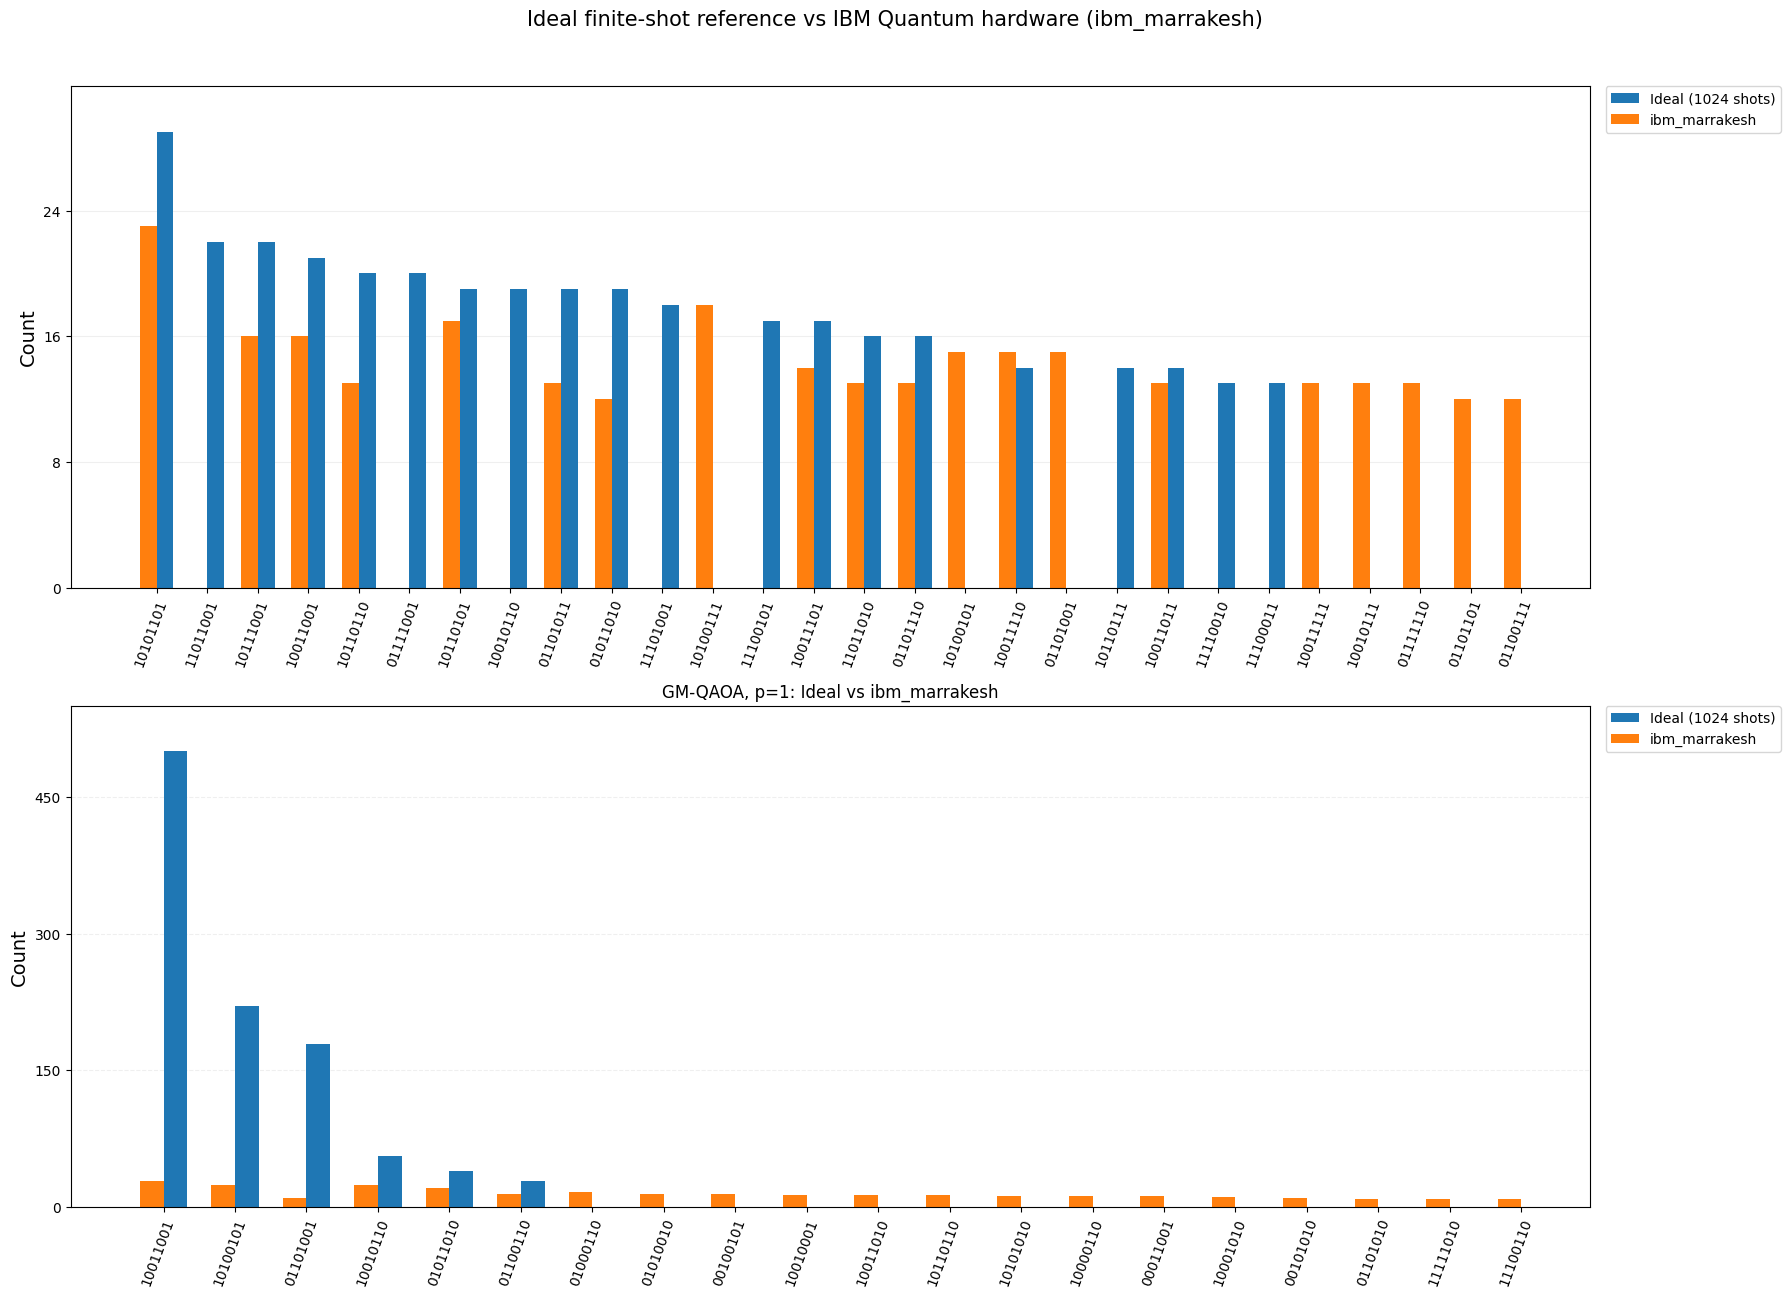

Saved: phase1_ideal_vs_ibm_marrakesh_histograms.png
Folded ISA circuit: Standard QAOA, p=1 on ibm_marrakesh


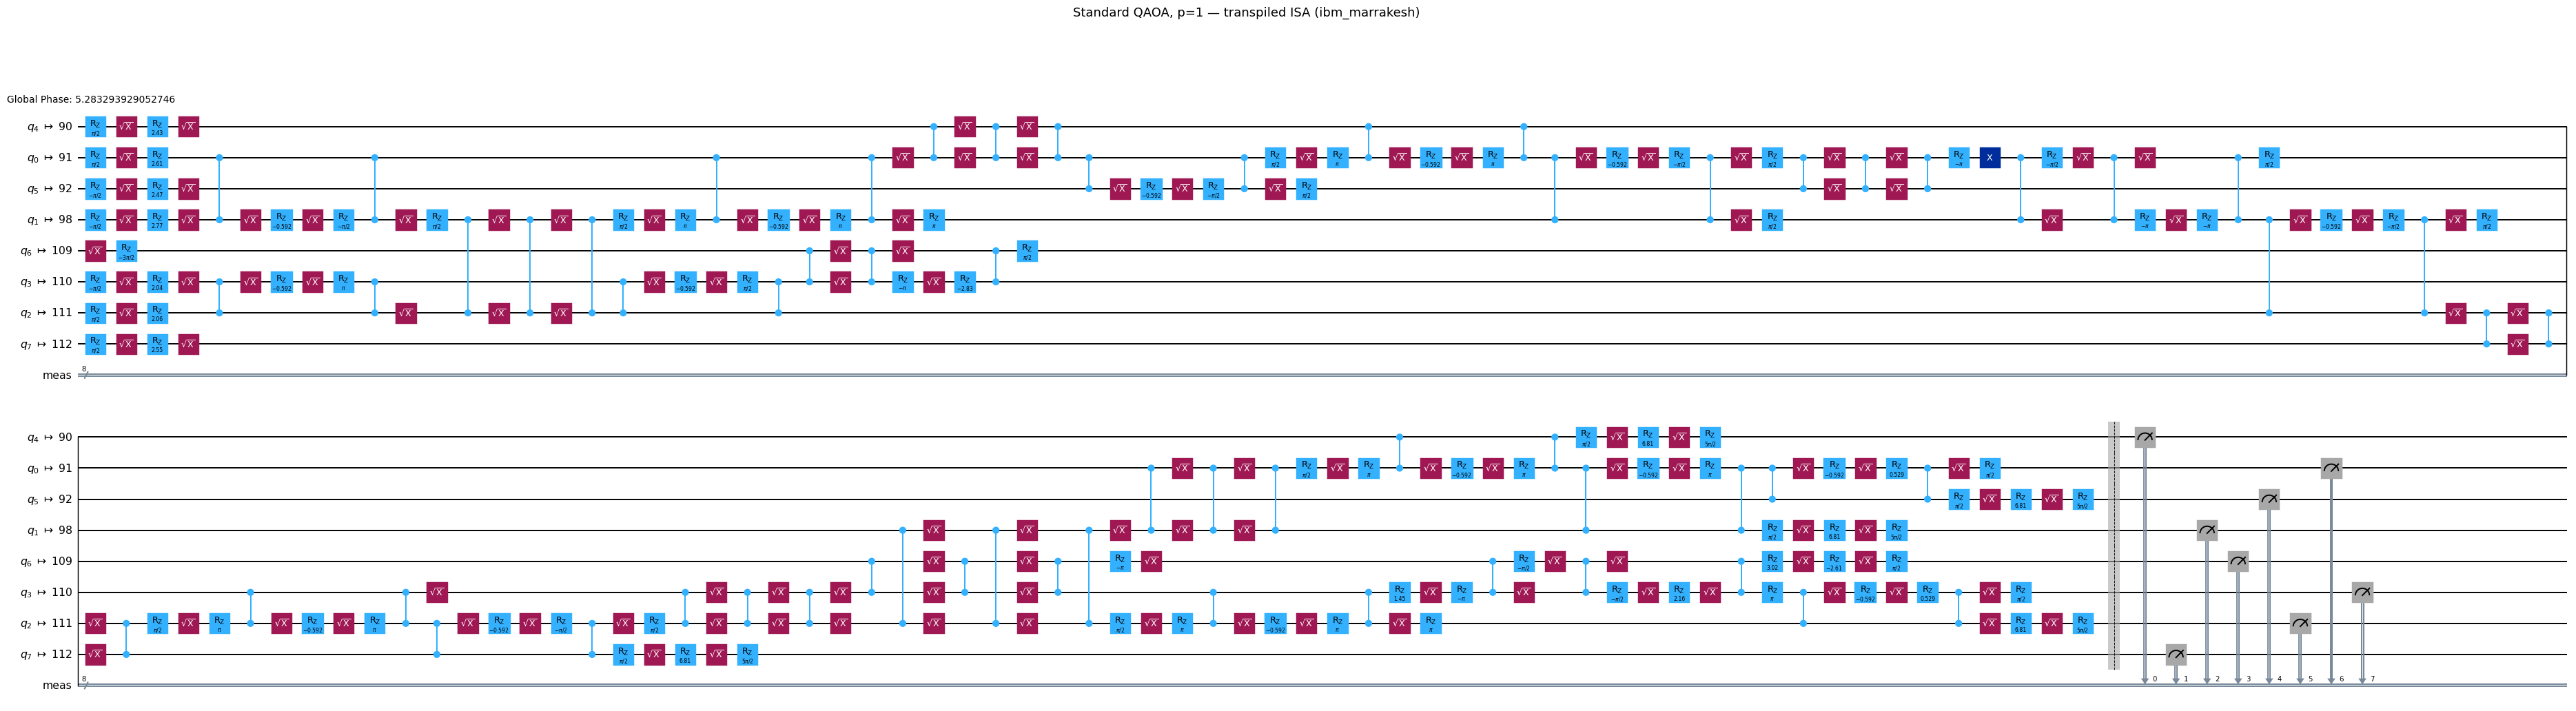

Saved: phase1_standard_qaoa_ibm_marrakesh_transpiled_folded.png
Folded ISA circuit: GM-QAOA, p=1 on ibm_marrakesh


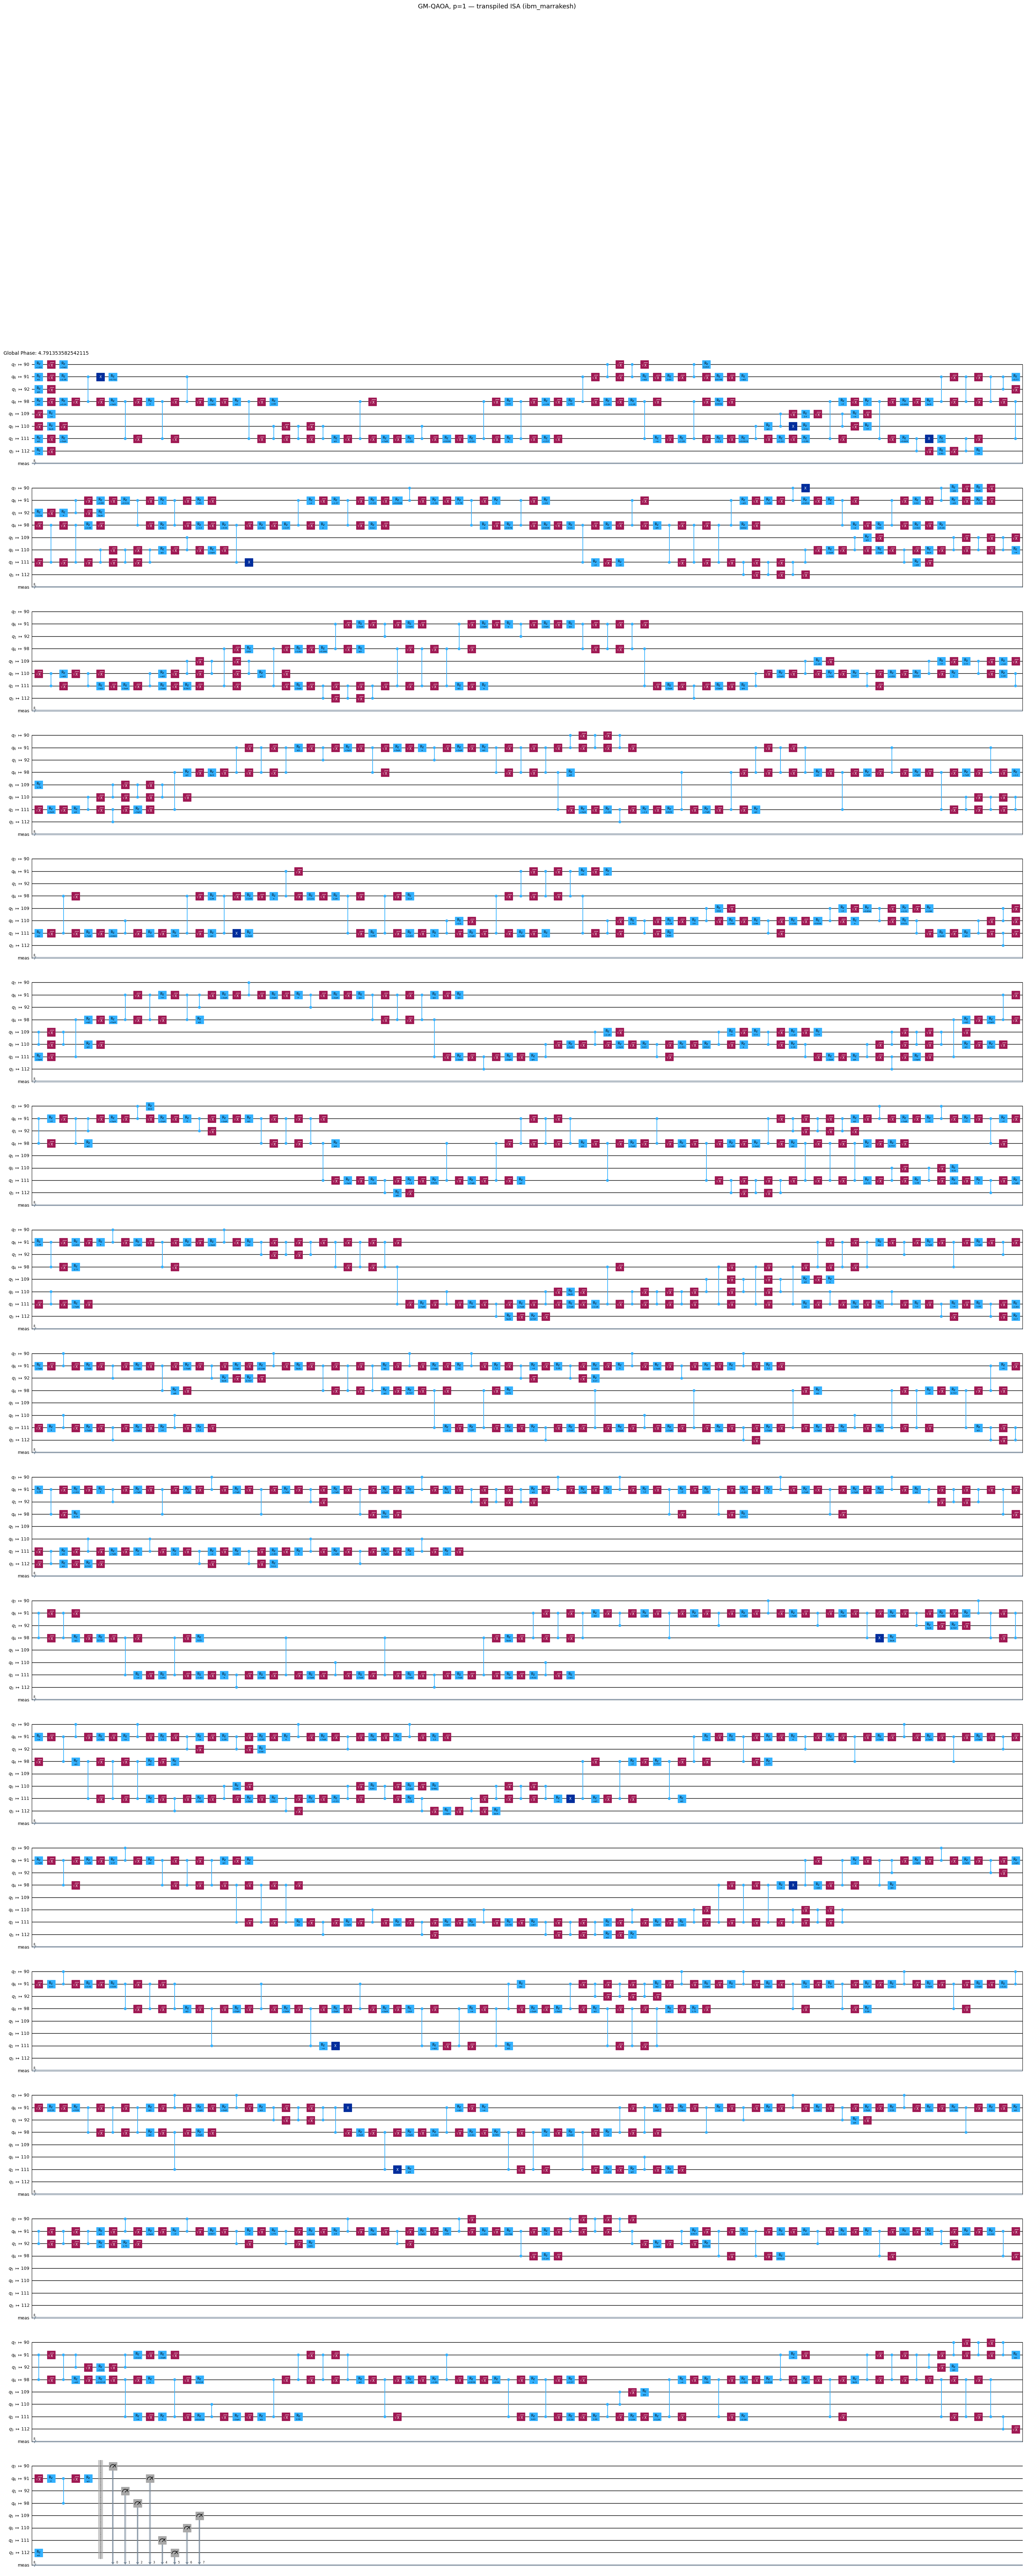

Saved: phase1_gm_qaoa_ibm_marrakesh_transpiled_folded.png
Updated phase1_results.json with the visualization manifest.


In [16]:
# Notebook cell 33/36 — Generate hardware-result visualizations
# Section 6.2 — Hardware visualizations and error comparison
# Phase-1 hardware visualizations: ideal-vs-QPU histograms and folded ISA circuits.

import json
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from qiskit.visualization import plot_histogram


def _finite_shot_ideal_counts(
    distribution: dict[str, float],
    shots: int,
    seed: int,
) -> dict[str, int]:
    """Create a reproducible finite-shot ideal reference for the histogram."""
    bitstrings = sorted(distribution)
    if not bitstrings or shots <= 0:
        return {}

    probabilities = np.asarray(
        [float(distribution[bitstring]) for bitstring in bitstrings],
        dtype=float,
    )
    probability_sum = float(probabilities.sum())
    if probability_sum <= 0.0:
        return {}

    probabilities /= probability_sum
    sampled = np.random.default_rng(seed).multinomial(
        int(shots),
        probabilities,
    )
    return {
        bitstring: int(count)
        for bitstring, count in zip(bitstrings, sampled)
        if int(count) > 0
    }


_hardware_visualizations_ready = (
    actual_execution_mode == "ibm_hardware"
    and execution_status == "completed"
)
_hardware_visualization_files = {}
_ideal_reference_counts = {}

if _hardware_visualizations_ready:
    _backend_slug = re.sub(
        r"[^A-Za-z0-9_.-]+",
        "_",
        str(target_backend_name),
    )
    _algorithm_titles = {
        "standard_qaoa": f"Standard QAOA, p={STANDARD_HARDWARE_P}",
        "gm_qaoa": f"GM-QAOA, p={GM_HARDWARE_P}",
    }
    _algorithms_with_counts = [
        algorithm
        for algorithm in ("standard_qaoa", "gm_qaoa")
        if counts_by_algorithm.get(algorithm)
    ]

    if _algorithms_with_counts:
        _histogram_figure, _histogram_axes = plt.subplots(
            len(_algorithms_with_counts),
            1,
            figsize=(18, 6.5 * len(_algorithms_with_counts)),
            squeeze=False,
        )
        _histogram_axes = _histogram_axes.ravel()

        for _algorithm_index, _algorithm in enumerate(_algorithms_with_counts):
            _ideal_counts = _finite_shot_ideal_counts(
                ideal_distributions[_algorithm],
                HARDWARE_SHOTS,
                SIMULATOR_SEED + _algorithm_index,
            )
            _ideal_reference_counts[_algorithm] = _ideal_counts

            plot_histogram(
                [
                    _ideal_counts,
                    counts_by_algorithm[_algorithm],
                ],
                legend=[
                    f"Ideal ({HARDWARE_SHOTS} shots)",
                    str(target_backend_name),
                ],
                sort="value_desc",
                number_to_keep=20,
                bar_labels=False,
                title=(
                    f"{_algorithm_titles[_algorithm]}: "
                    f"Ideal vs {target_backend_name}"
                ),
                ax=_histogram_axes[_algorithm_index],
            )
            _histogram_axes[_algorithm_index].tick_params(
                axis="x",
                labelrotation=70,
            )
            _histogram_axes[_algorithm_index].grid(
                axis="y",
                alpha=0.20,
            )

        _histogram_figure.suptitle(
            f"Ideal finite-shot reference vs IBM Quantum hardware "
            f"({target_backend_name})",
            fontsize=15,
            y=0.995,
        )
        _histogram_figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.975))

        _histogram_path = (
            f"phase1_ideal_vs_{_backend_slug}_histograms.png"
        )
        _histogram_figure.savefig(
            _histogram_path,
            dpi=180,
            bbox_inches="tight",
        )
        display(_histogram_figure)
        plt.close(_histogram_figure)
        _hardware_visualization_files[
            "ideal_vs_hardware_histograms"
        ] = _histogram_path
        print("Saved:", _histogram_path)
    else:
        warnings.warn(
            "The IBM hardware job completed, but no measurement counts "
            "were available for the histogram."
        )

    for _algorithm in ("standard_qaoa", "gm_qaoa"):
        _isa_circuit = isa_circuits.get(_algorithm)
        if _isa_circuit is None:
            continue

        try:
            print(
                f"Folded ISA circuit: {_algorithm_titles[_algorithm]} "
                f"on {target_backend_name}"
            )
            _circuit_figure = _isa_circuit.draw(
                output="mpl",
                fold=80,
                idle_wires=False,
                scale=0.70 if _algorithm == "standard_qaoa" else 0.55,
            )
            _circuit_figure.suptitle(
                f"{_algorithm_titles[_algorithm]} — transpiled ISA "
                f"({target_backend_name})",
                fontsize=13,
                y=1.002,
            )
            _circuit_path = (
                f"phase1_{_algorithm}_{_backend_slug}_"
                "transpiled_folded.png"
            )
            _circuit_figure.savefig(
                _circuit_path,
                dpi=160,
                bbox_inches="tight",
            )
            display(_circuit_figure)
            plt.close(_circuit_figure)
            _hardware_visualization_files[
                f"{_algorithm}_transpiled_folded"
            ] = _circuit_path
            print("Saved:", _circuit_path)
        except Exception as _drawing_error:
            warnings.warn(
                f"Folded circuit drawing failed for {_algorithm}: "
                f"{_drawing_error!r}"
            )
else:
    print(
        "Hardware visualizations skipped: they are generated only when "
        "actual_execution_mode == 'ibm_hardware' and "
        "execution_status == 'completed'."
    )

_phase1_visualization_manifest = {
    "standard_qaoa_depth_comparison": globals().get(
        "QAOA_DEPTH_COMPARISON_FIGURE_PATH"
    ),
    "hardware_condition_met": bool(_hardware_visualizations_ready),
    "hardware_files": _hardware_visualization_files,
}

if isinstance(globals().get("phase1_results"), dict):
    phase1_results["visualizations"] = _phase1_visualization_manifest
    if _ideal_reference_counts:
        phase1_results["hardware_or_fake_backend"][
            "ideal_finite_shot_reference_counts"
        ] = _ideal_reference_counts
    Path("phase1_results.json").write_text(
        json.dumps(
            json_ready(phase1_results),
            indent=2,
            ensure_ascii=False,
        ),
        encoding="utf-8",
    )
    print("Updated phase1_results.json with the visualization manifest.")


> **Notebook cell 34/36 — Define experiment tracking and report structure**

# 7. Documentation, Experiment Tracking, and Final Report Structure

**Primary owner:** Ilia Fazeli  
**Support:** MarcosJ, Jiya Maurya  
**Decision rationale:** this track is responsible for scientific traceability. Documentation is not secondary; it is what makes the benchmark reproducible and the final conclusions defensible.

## Goal

Maintain a clear record of assumptions, instances, solvers, parameters, seeds, metrics, and conclusions.

Every experiment should be logged as a structured record:

$$
\mathcal{E} = (\mathrm{instance}, \mathrm{solver}, \mathrm{parameters}, \mathrm{seed}, \mathrm{runtime}, \mathrm{score}, \mathrm{energy}, \mathrm{feasibility}, \mathrm{notes})
$$

The final report should not overclaim quantum advantage. Instead, it should clearly state:

1. What was formulated.
2. What was implemented.
3. What was compared.
4. What worked.
5. What failed or did not scale.
6. What the NISQ limitations imply.

## Track 5 deliverables

1. Report outline from Week 1.
2. Experiment log schema.
3. Results table or dashboard structure.
4. Limitations section covering NISQ noise, scaling, and hardware constraints.
5. Related work skeleton.
6. Final report integration.
7. Claims checklist to avoid unsupported conclusions.

## Recommended final report structure

1. Abstract.
2. Introduction and motivation.
3. Assignment problem definition.
4. QUBO formulation.
5. Classical baselines.
6. QAOA implementation.
7. Experimental setup.
8. Results.
9. Discussion and limitations.
10. Conclusion and future work.


In [17]:
# Notebook cell 35/36 — Build the experiment log and claims checklist
# Track 5 execution cell: create the expanded experiment log and claims checklist.

experiment_log_columns = [
    "experiment_id",
    "track_owner",
    "instance_id",
    "n_agents",
    "n_resources",
    "constraint_mode",
    "capacities",
    "seed",
    "solver",
    "solver_family",
    "parameters",
    "score",
    "qubo_energy",
    "feasible",
    "optimality_gap",
    "runtime_s",
    "backend",
    "execution_mode",
    "job_id",
    "circuit_depth",
    "two_qubit_gates",
    "notes",
]

experiment_rows = []
experiment_counter = 1

for _, row in classical_benchmark_all.iterrows():
    instance = INSTANCES[row["instance_id"]]
    experiment_rows.append({
        "experiment_id": f"exp_{experiment_counter:03d}",
        "track_owner": "Satkar Juneja",
        "instance_id": row["instance_id"],
        "n_agents": row["n_agents"],
        "n_resources": row["n_resources"],
        "constraint_mode": row["constraint_mode"],
        "capacities": row["capacities"],
        "seed": 2026 if row["solver"] == "simulated_annealing" else None,
        "solver": row["solver"],
        "solver_family": "classical",
        "parameters": "single execution",
        "score": row["score"],
        "qubo_energy": None,
        "feasible": row["feasible"],
        "optimality_gap": row["optimality_gap"],
        "runtime_s": row["runtime_s"],
        "backend": None,
        "execution_mode": "classical",
        "job_id": None,
        "circuit_depth": None,
        "two_qubit_gates": None,
        "notes": "same instance and score definition",
    })
    experiment_counter += 1

for _, row in qaoa_depth_sweep_results.iterrows():
    experiment_rows.append({
        "experiment_id": f"exp_{experiment_counter:03d}",
        "track_owner": "MarcosJ",
        "instance_id": row["instance_id"],
        "n_agents": row["n_agents"],
        "n_resources": row["n_resources"],
        "constraint_mode": row["constraint_mode"],
        "capacities": row["capacities"],
        "seed": 2026,
        "solver": "standard_qaoa",
        "solver_family": "quantum_statevector",
        "parameters": f"p={int(row['p'])}; COBYLA; shots={int(row['shots'])}",
        "score": row["best_sampled_feasible_score"],
        "qubo_energy": row["best_sampled_feasible_qubo_energy"],
        "feasible": bool(np.isfinite(row["best_sampled_feasible_score"])),
        "optimality_gap": row["relative_optimization_gap"],
        "runtime_s": row["runtime_s"],
        "backend": "statevector",
        "execution_mode": "ideal_simulation",
        "job_id": None,
        "circuit_depth": row["ideal_circuit_depth"],
        "two_qubit_gates": None,
        "notes": "depth sweep p in {1,2,3}; one deterministic run per p",
    })
    experiment_counter += 1

for _, row in gm_ideal_summary.iterrows():
    experiment_rows.append({
        "experiment_id": f"exp_{experiment_counter:03d}",
        "track_owner": "Project 20",
        "instance_id": row["instance_id"],
        "n_agents": row["n_agents"],
        "n_resources": row["n_resources"],
        "constraint_mode": row["constraint_mode"],
        "capacities": row["capacities"],
        "seed": None,
        "solver": "gm_qaoa",
        "solver_family": "quantum_statevector",
        "parameters": f"p={int(row['p'])}; feasible-state mixer",
        "score": row["best_score"],
        "qubo_energy": -float(row["best_score"]),
        "feasible": bool(np.isclose(row["feasible_probability"], 1.0)),
        "optimality_gap": row["score_gap"] / (abs(row["classical_score"]) + 1e-12),
        "runtime_s": row["runtime_s"],
        "backend": "statevector",
        "execution_mode": "ideal_simulation",
        "job_id": None,
        "circuit_depth": row["ideal_circuit_depth"],
        "two_qubit_gates": None,
        "notes": "fixed small-instance feasible-state preparation",
    })
    experiment_counter += 1

if "hardware_summary" in globals() and not hardware_summary.empty:
    for _, row in hardware_summary.iterrows():
        instance = INSTANCES[row["instance_id"]]
        experiment_rows.append({
            "experiment_id": f"exp_{experiment_counter:03d}",
            "track_owner": "Project 20",
            "instance_id": row["instance_id"],
            "n_agents": instance.n_agents,
            "n_resources": instance.n_resources,
            "constraint_mode": instance.constraint_mode,
            "capacities": instance.capacities.tolist(),
            "seed": SIMULATOR_SEED if row["execution_mode"] != "ibm_hardware" else None,
            "solver": row["algorithm"],
            "solver_family": "quantum_runtime",
            "parameters": (
                f"p={STANDARD_HARDWARE_P if row['algorithm']=='standard_qaoa' else GM_HARDWARE_P}; "
                f"shots={HARDWARE_SHOTS}"
            ),
            "score": row["best_feasible_score"],
            "qubo_energy": row["minimum_qubo_energy_found"],
            "feasible": bool(np.isfinite(row["best_feasible_score"])),
            "optimality_gap": row["relative_optimization_gap"],
            "runtime_s": row["execution_wall_time_s"],
            "backend": row["backend"],
            "execution_mode": row["execution_mode"],
            "job_id": row["job_id"],
            "circuit_depth": row["transpiled_depth"],
            "two_qubit_gates": row["transpiled_two_qubit_gates"],
            "notes": row["execution_status"],
        })
        experiment_counter += 1

experiment_log = pd.DataFrame(experiment_rows, columns=experiment_log_columns)

claims_checklist = pd.DataFrame([
    {
        "claim_type": "1-to-1 feasibility",
        "allowed": "Yes",
        "required_evidence": "Decoded matrix and row/column checks for 3x3 and 4x4.",
    },
    {
        "claim_type": "exact-capacity 1-to-N feasibility",
        "allowed": "Yes for fixed C=[2,2]",
        "required_evidence": "Each row sums to one and resource columns equal the capacity vector.",
    },
    {
        "claim_type": "QAOA depth comparison",
        "allowed": "Yes for p in {1,2,3}",
        "required_evidence": "One deterministic ideal run per instance and p.",
    },
    {
        "claim_type": "GM-QAOA feasible-subspace preservation",
        "allowed": "Yes, in ideal simulation",
        "required_evidence": "Uniform state-preparation fidelity and total feasible probability equal to one.",
    },
    {
        "claim_type": "hardware result",
        "allowed": "Only when execution_mode is ibm_hardware and status is completed",
        "required_evidence": "Backend, job ID, counts, transpilation, gap, fidelity estimate, and timing.",
    },
    {
        "claim_type": "general scalable GM-QAOA preparation",
        "allowed": "No",
        "required_evidence": "Phase 1 uses fixed small-instance state-preparation circuits.",
    },
    {
        "claim_type": "quantum advantage",
        "allowed": "No",
        "required_evidence": "The current experiment does not establish an asymptotic or practical advantage.",
    },
])

print("Experiment log:")
display(experiment_log)
print("Claims checklist:")
display(claims_checklist)

experiment_log.to_csv("phase1_experiment_log.csv", index=False)
claims_checklist.to_csv("phase1_claims_checklist.csv", index=False)
print("Saved: phase1_experiment_log.csv and phase1_claims_checklist.csv")


Experiment log:


,experiment_id,track_owner,instance_id,n_agents,n_resources,constraint_mode,capacities,seed,solver,solver_family,...,qubo_energy,feasible,optimality_gap,runtime_s,backend,execution_mode,job_id,circuit_depth,two_qubit_gates,notes
0,exp_001,Satkar Juneja,reference_3x3,3,3,one_to_one,"[1, 1, 1]",NaN,exact_bruteforce,classical,...,NaN,True,0.000000,0.000466,None,classical,None,NaN,NaN,same instance and score definition
1,exp_002,Satkar Juneja,reference_3x3,3,3,one_to_one,"[1, 1, 1]",NaN,hungarian,classical,...,NaN,True,0.000000,0.000203,None,classical,None,NaN,NaN,same instance and score definition
2,exp_003,Satkar Juneja,reference_3x3,3,3,one_to_one,"[1, 1, 1]",NaN,greedy,classical,...,NaN,True,0.000000,0.003466,None,classical,None,NaN,NaN,same instance and score definition
3,exp_004,Satkar Juneja,reference_3x3,3,3,one_to_one,"[1, 1, 1]",2026.0,simulated_annealing,classical,...,NaN,True,0.000000,1.909880,None,classical,None,NaN,NaN,same instance and score definition
4,exp_005,Satkar Juneja,one_to_one_4x4,4,4,one_to_one,"[1, 1, 1, 1]",NaN,exact_bruteforce,classical,...,NaN,True,0.000000,0.003566,None,classical,None,NaN,NaN,same instance and score definition
5,exp_006,Satkar Juneja,one_to_one_4x4,4,4,one_to_one,"[1, 1, 1, 1]",NaN,hungarian,classical,...,NaN,True,0.000000,0.000151,None,classical,None,NaN,NaN,same instance and score definition
6,exp_007,Satkar Juneja,one_to_one_4x4,4,4,one_to_one,"[1, 1, 1, 1]",NaN,greedy,classical,...,NaN,True,0.280000,0.000417,None,classical,None,NaN,NaN,same instance and score definition
7,exp_008,Satkar Juneja,one_to_one_4x4,4,4,one_to_one,"[1, 1, 1, 1]",2026.0,simulated_annealing,classical,...,NaN,True,0.070000,2.707101,None,classical,None,NaN,NaN,same instance and score definition
8,exp_009,Satkar Juneja,exact_capacity_4x2,4,2,exact_capacity,"[2, 2]",NaN,exact_bruteforce,classical,...,NaN,True,0.000000,0.000305,None,classical,None,NaN,NaN,same instance and score definition
9,exp_010,Satkar Juneja,exact_capacity_4x2,4,2,exact_capacity,"[2, 2]",NaN,greedy,classical,...,NaN,True,0.000000,0.000309,None,classical,None,NaN,NaN,same instance and score definition


Claims checklist:


,claim_type,allowed,required_evidence
0,1-to-1 feasibility,Yes,Decoded matrix and row/column checks for 3x3 a...
1,exact-capacity 1-to-N feasibility,"Yes for fixed C=[2,2]",Each row sums to one and resource columns equa...
2,QAOA depth comparison,"Yes for p in {1,2,3}",One deterministic ideal run per instance and p.
3,GM-QAOA feasible-subspace preservation,"Yes, in ideal simulation",Uniform state-preparation fidelity and total f...
4,hardware result,Only when execution_mode is ibm_hardware and s...,"Backend, job ID, counts, transpilation, gap, f..."
5,general scalable GM-QAOA preparation,No,Phase 1 uses fixed small-instance state-prepar...
6,quantum advantage,No,The current experiment does not establish an a...


Saved: phase1_experiment_log.csv and phase1_claims_checklist.csv


In [18]:
# Notebook cell 36/36 — Summarize compliance and scientific conclusions
# Phase-1 conclusions and compliance summary.

from pathlib import Path


compliance_matrix = pd.DataFrame([
    {
        "reference": "depth.pdf / deep.ipynb",
        "requirement": "Preserve original 3x3, p=1 execution",
        "status": "Met",
        "evidence": "reference_3x3 with FIXED_P=1 remains an explicit alias and log entry.",
    },
    {
        "reference": "depth.pdf / deep.ipynb",
        "requirement": "Add 4x4 one-to-one instance",
        "status": "Met",
        "evidence": "one_to_one_4x4 uses exact row constraints and unit resource capacity.",
    },
    {
        "reference": "depth.pdf / deep.ipynb",
        "requirement": "Add 4x2 exact capacities C=[2,2]",
        "status": "Met",
        "evidence": "exact_capacity_4x2 uses the squared exact-capacity penalty.",
    },
    {
        "reference": "QI26-20",
        "requirement": "QAOA p sweep on all three instances",
        "status": "Met in ideal simulation",
        "evidence": "p in {1,2,3}, one deterministic optimization per pair.",
    },
    {
        "reference": "Bärtschi--Eidenbenz 2020",
        "requirement": "Equal superposition of feasible states",
        "status": "Met for the three fixed instances",
        "evidence": "State-preparation fidelity is verified against the exact feasible state.",
    },
    {
        "reference": "Bärtschi--Eidenbenz 2020",
        "requirement": "Parameterized Grover mixer and feasible-subspace preservation",
        "status": "Met ideally",
        "evidence": "U_S D_0(beta) U_S^dagger is compared with the feasible-subspace calculation.",
    },
    {
        "reference": "IBM Quantum execution",
        "requirement": "Standard QAOA and GM-QAOA transpilation/execution",
        "status": "Ready; result depends on selected mode",
        "evidence": "Both circuits use the same backend, pass manager, shots, and exported schema.",
    },
    {
        "reference": "Bärtschi--Eidenbenz 2020",
        "requirement": "General O(n^3)-gate permutation preparation",
        "status": "Not claimed",
        "evidence": "The Phase-1 circuits are exact fixed-size constructions for n=3, n=4, and 4x2.",
    },
])

best_standard_by_instance = (
    qaoa_depth_sweep_results.sort_values(
        ["instance_id", "absolute_optimization_gap", "optimal_probability"],
        ascending=[True, True, False],
    ).groupby("instance_id", as_index=False).first()
)

conclusions = [
    "The generalized QUBO supports the original one-to-one collision penalty and the exact-capacity penalty with C=[2,2].",
    "The standard-QAOA benchmark contains exactly nine ideal runs: three fixed instances and p in {1,2,3}, without additional parameter sweeps or multiple seeds.",
    "The original reference_3x3, p=1 experiment remains directly addressable through the original aliases.",
    "GM-QAOA prepares only feasible assignments for the three fixed instances and verifies the complete ideal circuit against the feasible-subspace calculation.",
    "Hardware claims are valid only when phase1_results.json records execution_mode='ibm_hardware' and execution_status='completed'.",
    "No quantum-advantage or general scalability claim follows from these small-instance experiments.",
]

print("Best standard-QAOA depth per instance under the recorded metric order:")
display(best_standard_by_instance[
    [
        "instance_id",
        "p",
        "absolute_optimization_gap",
        "feasible_probability",
        "optimal_probability",
        "ideal_circuit_depth",
    ]
])
print("Phase-1 compliance matrix:")
display(compliance_matrix)
print("Phase-1 conclusions:")
for index, conclusion in enumerate(conclusions, start=1):
    print(f"{index}. {conclusion}")

compliance_matrix.to_csv("phase1_compliance_matrix.csv", index=False)
Path("phase1_conclusions.txt").write_text(
    "\n".join(f"{index}. {text}" for index, text in enumerate(conclusions, start=1)),
    encoding="utf-8",
)
print("Saved: phase1_compliance_matrix.csv and phase1_conclusions.txt")


Best standard-QAOA depth per instance under the recorded metric order:


,instance_id,p,absolute_optimization_gap,feasible_probability,optimal_probability,ideal_circuit_depth
0,exact_capacity_4x2,3,0.0,0.439911,0.061093,55
1,one_to_one_4x4,2,0.0,0.039986,0.001629,59
2,reference_3x3,3,0.0,0.118618,0.041527,61


Phase-1 compliance matrix:


,reference,requirement,status,evidence
0,depth.pdf / deep.ipynb,"Preserve original 3x3, p=1 execution",Met,reference_3x3 with FIXED_P=1 remains an explic...
1,depth.pdf / deep.ipynb,Add 4x4 one-to-one instance,Met,one_to_one_4x4 uses exact row constraints and ...
2,depth.pdf / deep.ipynb,"Add 4x2 exact capacities C=[2,2]",Met,exact_capacity_4x2 uses the squared exact-capa...
3,QI26-20,QAOA p sweep on all three instances,Met in ideal simulation,"p in {1,2,3}, one deterministic optimization p..."
4,Bärtschi--Eidenbenz 2020,Equal superposition of feasible states,Met for the three fixed instances,State-preparation fidelity is verified against...
5,Bärtschi--Eidenbenz 2020,Parameterized Grover mixer and feasible-subspa...,Met ideally,U_S D_0(beta) U_S^dagger is compared with the ...
6,IBM Quantum execution,Standard QAOA and GM-QAOA transpilation/execution,Ready; result depends on selected mode,"Both circuits use the same backend, pass manag..."
7,Bärtschi--Eidenbenz 2020,General O(n^3)-gate permutation preparation,Not claimed,The Phase-1 circuits are exact fixed-size cons...


Phase-1 conclusions:
1. The generalized QUBO supports the original one-to-one collision penalty and the exact-capacity penalty with C=[2,2].
2. The standard-QAOA benchmark contains exactly nine ideal runs: three fixed instances and p in {1,2,3}, without additional parameter sweeps or multiple seeds.
3. The original reference_3x3, p=1 experiment remains directly addressable through the original aliases.
4. GM-QAOA prepares only feasible assignments for the three fixed instances and verifies the complete ideal circuit against the feasible-subspace calculation.
5. Hardware claims are valid only when phase1_results.json records execution_mode='ibm_hardware' and execution_status='completed'.
6. No quantum-advantage or general scalability claim follows from these small-instance experiments.
Saved: phase1_compliance_matrix.csv and phase1_conclusions.txt
